# Lab 4 — Measuring an object detector

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kleinric/cv-labs/blob/main/lab-04.ipynb)

**COMS4036A / COMS7050A Computer Vision · Week 4**

Groups of up to three; one member submits the group's notebook (`.ipynb`) on Moodle. Every member must be able to explain every cell.

Companion reading is [Chapter 4 of the course book](https://courses.ms.wits.ac.za/~richard/cv/book/chapters/04-detection-two-stage.html). Nothing is trained this week. A pretrained detector is handed to you and the work is measuring it. Every quantity in the detection literature is arithmetic small enough to do on paper: IoU, precision, recall, average precision, mAP. You do it on paper first, then in code, then against the library's version.

The rung of the skills ladder is **implement IoU and mAP yourself before trusting a library's version**. The second theme is evaluation hygiene: what a number computed on 200 images is worth when the benchmark has 4,952.

## 0. GPU, W&B, and VOC 2007

Open this notebook in [Colab](https://colab.research.google.com) with the badge above, then **File ▸ Save a copy in Drive**. Set **Runtime ▸ Change runtime type** to a GPU, and log in to W&B as in the last two labs; this lab logs to a project called `cv-lab4`.

In [1]:
# Group members — fill in before submitting.
MEMBERS = [
    # ("Student name", "Student number"),
    ( "Nkosenhle Ndlovu", "2539199" )
]

for name, number in MEMBERS:
    print(f"{number}  {name}")

2539199  Nkosenhle Ndlovu


In [2]:
!nvidia-smi --query-gpu=name,memory.total --format=csv

name, memory.total [MiB]
Tesla T4, 15360 MiB


In [3]:
import wandb
wandb.login()

/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 2539199 (2539199-wits) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

The data is the test half of [PASCAL VOC 2007](http://host.robots.ox.ac.uk/pascal/VOC/voc2007/) (Everingham et al., 2010): 4,952 photographs, 20 object classes, one box per object, about 450 MB. Every mAP number in Chapter 4's R-CNN lineage is quoted on this set, which is the reason for choosing it. The download takes a minute or two.

In [4]:
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.patches import Rectangle
from torchvision.datasets import VOCDetection
from torchvision.models.detection import (
    FasterRCNN_ResNet50_FPN_V2_Weights,
    fasterrcnn_resnet50_fpn_v2,
)
from torchvision.models.detection.transform import resize_boxes
from torchvision.ops import box_iou, nms

DEV = "cuda" if torch.cuda.is_available() else "cpu"


def seed_everything(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(0)
voc = VOCDetection(".", year="2007", image_set="test", download=True)
print("device:", DEV, "· images:", len(voc))

100%|██████████| 451M/451M [00:17<00:00, 26.0MB/s]


device: cuda · images: 4952


The 20 class names, in the order VOC uses, and the seeded subset everything below is measured on. Running the whole test set takes a quarter of an hour on a T4; 200 images takes under a minute. Section 3 asks what that shortcut costs.

In [5]:
VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle", "bus", "car", "cat",
    "chair", "cow", "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor",
]

def subset(seed, n=200):
    return sorted(np.random.RandomState(seed).choice(len(voc), n,
                                                     replace=False).tolist())

SUBSET = subset(0)
print(len(SUBSET), "images ·", SUBSET[:5])

200 images · [12, 39, 42, 49, 72]


## 1. Inspect the detector output

A classifier returns one vector per image, the same shape every time. A detector returns a list whose length depends on the photograph, and the length is part of what is being judged. That is what makes the metric awkward, and the first thing to do is look at the output.

In [6]:
weights = FasterRCNN_ResNet50_FPN_V2_Weights.COCO_V1
model = fasterrcnn_resnet50_fpn_v2(weights=weights).eval().to(DEV)
prep = weights.transforms()
print(f"{sum(p.numel() for p in model.parameters()):,} parameters")
print("score_thresh", model.roi_heads.score_thresh,
      "· nms_thresh", model.roi_heads.nms_thresh,
      "· detections_per_img", model.roi_heads.detections_per_img)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 185MB/s]


43,712,278 parameters
score_thresh 0.05 · nms_thresh 0.5 · detections_per_img 100


Those three numbers are the detector's output policy, and none of them is part of the network. Sections 4 and 6 change them.

**Q1.1.** `voc[i]` returns a `(PIL image, dict)` pair, and the dict is the VOC XML file parsed into nested dictionaries: `target["annotation"]["object"]` is a list, one entry per annotated object, each with a `name`, a `bndbox` of `xmin`/`ymin`/`xmax`/`ymax` strings, and a `difficult` flag. Write `ground_truth(target)` returning three arrays: boxes as float $(x_1, y_1, x_2, y_2)$, integer labels indexing `VOC_CLASSES`, and a boolean `difficult`. Then report, over `SUBSET`: the number of annotated objects, how many are flagged difficult, the mean and maximum number of objects per image, and the count of non-difficult objects in each class.

In [7]:
def ground_truth(target):
    """VOC XML dict -> (boxes (N,4) float, labels (N,) int, difficult (N,) bool)."""
    objs = target["annotation"]["object"]
    if isinstance(objs, dict):  # torchvision gives a list, but guard a lone object
        objs = [objs]

    boxes, labels, difficult = [], [], []
    for o in objs:
        bb = o["bndbox"]
        boxes.append([float(bb["xmin"]), float(bb["ymin"]),
                      float(bb["xmax"]), float(bb["ymax"])])
        labels.append(VOC_CLASSES.index(o["name"]))
        difficult.append(o.get("difficult", "0") == "1")

    return (np.asarray(boxes, dtype=np.float64).reshape(-1, 4),
            np.asarray(labels, dtype=np.int64),
            np.asarray(difficult, dtype=bool))


# cache the subset's ground truth once; every section below reuses it
GT = {i: ground_truth(voc[i][1]) for i in SUBSET}

counts = np.array([len(GT[i][0]) for i in SUBSET])
n_obj = int(counts.sum())
n_diff = int(sum(int(GT[i][2].sum()) for i in SUBSET))

print(f"images             : {len(SUBSET)}")
print(f"annotated objects  : {n_obj}")
print(f"flagged difficult  : {n_diff}  ({100 * n_diff / n_obj:.1f}%)")
print(f"objects per image  : mean {counts.mean():.2f}, max {counts.max()}")

CLASS_COUNTS = np.zeros(len(VOC_CLASSES), dtype=int)
for i in SUBSET:
    _, lab, dif = GT[i]
    for c in lab[~dif]:
        CLASS_COUNTS[c] += 1

print("\nnon-difficult objects per class")
for c, name in enumerate(VOC_CLASSES):
    bar = "#" * int(round(40 * CLASS_COUNTS[c] / max(CLASS_COUNTS.max(), 1)))
    print(f"  {name:12s} {CLASS_COUNTS[c]:4d}  {bar}")
print(f"  {'TOTAL':12s} {CLASS_COUNTS.sum():4d}")

images             : 200
annotated objects  : 535
flagged difficult  : 115  (21.5%)
objects per image  : mean 2.67, max 22

non-difficult objects per class
  aeroplane      17  #####
  bicycle        13  ####
  bird           13  ####
  boat            8  ##
  bottle         13  ####
  bus             6  ##
  car            45  #############
  cat            20  ######
  chair          31  #########
  cow             9  ###
  diningtable     9  ###
  dog            30  #########
  horse          10  ###
  motorbike       7  ##
  person        136  ########################################
  pottedplant     8  ##
  sheep          13  ####
  sofa            7  ##
  train           9  ###
  tvmonitor      16  #####
  TOTAL         420


**Q1.2.** The detector was not trained on VOC. It was trained on COCO, whose 91-slot label space is `weights.meta["categories"]`, and its label 1 is not VOC's class 1. All 20 VOC classes appear in COCO, but six of the names differ. Build `COCO_TO_VOC`, a dict from COCO label index to VOC class index, and print the six pairs whose names are not identical. Detections in the other 71 slots are dropped from here on: VOC does not annotate those categories, so a correct detection of a truck or a bench would score as a false positive.

In [8]:
# YOUR CODE HERE
COCO_CATEGORIES = weights.meta["categories"]

# the six VOC class names COCO spells differently
VOC_TO_COCO_NAME = {
    "aeroplane": "airplane",
    "diningtable": "dining table",
    "motorbike": "motorcycle",
    "pottedplant": "potted plant",
    "sofa": "couch",
    "tvmonitor": "tv",
}

COCO_TO_VOC = {}
for voc_idx, voc_name in enumerate(VOC_CLASSES):
    coco_name = VOC_TO_COCO_NAME.get(voc_name, voc_name)
    COCO_TO_VOC[COCO_CATEGORIES.index(coco_name)] = voc_idx

assert len(COCO_TO_VOC) == 20, "each VOC class must land in exactly one COCO slot"

# lookup array: COCO label -> VOC label, -1 for the slots VOC does not annotate
COCO2VOC = np.full(len(COCO_CATEGORIES), -1, dtype=np.int64)
for coco_idx, voc_idx in COCO_TO_VOC.items():
    COCO2VOC[coco_idx] = voc_idx

print(f"{len(COCO_CATEGORIES)} COCO slots - {len(COCO_TO_VOC)} mapped to VOC - "
      f"{int((COCO2VOC < 0).sum())} dropped\n")
print("the six names that differ:")
for voc_name, coco_name in VOC_TO_COCO_NAME.items():
    print(f"  VOC {voc_name:12s} -> COCO slot {COCO_CATEGORIES.index(coco_name):2d} "
          f"{coco_name!r}")
print("\nthe other fourteen are spelled identically:")
print("  " + ", ".join(n for n in VOC_CLASSES if n not in VOC_TO_COCO_NAME))

91 COCO slots - 20 mapped to VOC - 71 dropped

the six names that differ:
  VOC aeroplane    -> COCO slot  5 'airplane'
  VOC diningtable  -> COCO slot 67 'dining table'
  VOC motorbike    -> COCO slot  4 'motorcycle'
  VOC pottedplant  -> COCO slot 64 'potted plant'
  VOC sofa         -> COCO slot 63 'couch'
  VOC tvmonitor    -> COCO slot 72 'tv'

the other fourteen are spelled identically:
  bicycle, bird, boat, bottle, bus, car, cat, chair, cow, dog, horse, person, sheep, train


**Q1.3.** Take the busiest image in `SUBSET`, the one with the most annotated objects, and run the model on it: `model([prep(img).to(DEV)])[0]`, inside `torch.no_grad()`. Draw two panels side by side: the ground-truth boxes, and the detections scoring above 0.5 labelled with class and score. Print the number of detections above 0.05, above 0.5 and above 0.9, and the number of annotated objects.

image 4096 - 500x375 px
  detections above 0.05:  99  (56 in a VOC class)
  detections above 0.50:  24  (21 in a VOC class)
  detections above 0.90:   9  (9 in a VOC class)
  annotated objects  :  22  (11 flagged difficult)

   #  class           w x h       area  small  difficult
   0  diningtable   427 x  162     69174      -          -
   1  diningtable    63 x   70      4410      -        yes
   2  chair          43 x   83      3569      -        yes
   3  chair         141 x   63      8883      -        yes
   4  chair         105 x   65      6825      -          -
   5  chair          70 x  105      7350      -        yes
   6  chair         143 x  128     18304      -          -
   7  chair          79 x  143     11297      -          -
   8  chair          41 x   76      3116      -        yes
   9  chair          11 x   29       319    yes        yes
  10  chair          12 x   10       120    yes        yes
  11  chair          13 x    6        78    yes        yes
  12  chai

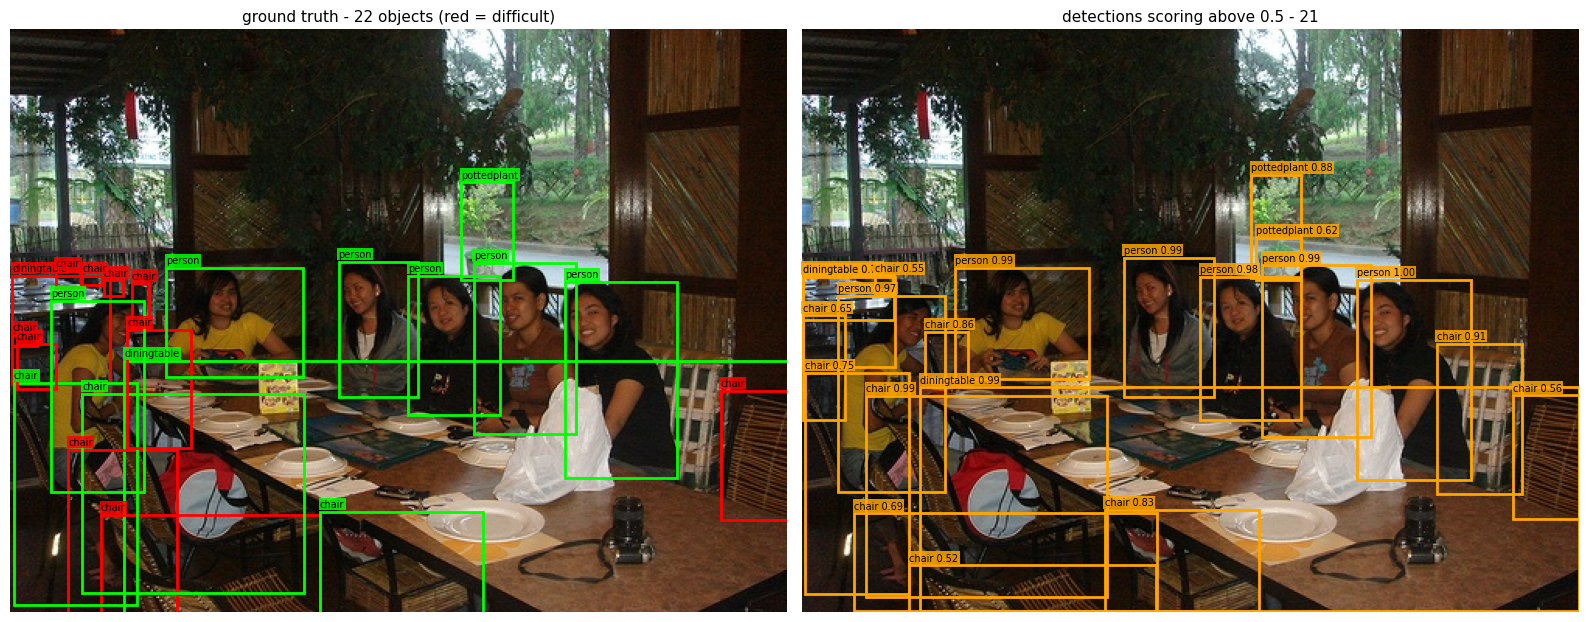

In [9]:
# YOUR CODE HERE
BUSIEST = max(SUBSET, key=lambda i: len(GT[i][0]))
img, target = voc[BUSIEST]
gt_boxes, gt_labels, gt_diff = GT[BUSIEST]

with torch.no_grad():
    out = model([prep(img).to(DEV)])[0]

d_boxes = out["boxes"].cpu().numpy()
d_scores = out["scores"].cpu().numpy()
d_voc = COCO2VOC[out["labels"].cpu().numpy()]  # -1 outside VOC's 20 classes

print(f"image {BUSIEST} - {img.size[0]}x{img.size[1]} px")
for t in (0.05, 0.5, 0.9):
    n_all = int((d_scores > t).sum())
    n_voc = int(((d_scores > t) & (d_voc >= 0)).sum())
    print(f"  detections above {t:.2f}: {n_all:3d}  ({n_voc} in a VOC class)")
print(f"  annotated objects  : {len(gt_boxes):3d}  "
      f"({int(gt_diff.sum())} flagged difficult)")

# per-object detail, for Q1.4: COCO calls an object "small" below 32x32 pixels
print("\n   #  class           w x h       area  small  difficult")
for k in range(len(gt_boxes)):
    x1, y1, x2, y2 = gt_boxes[k]
    w, h = x2 - x1, y2 - y1
    print(f"  {k:2d}  {VOC_CLASSES[gt_labels[k]]:12s} {w:4.0f} x {h:4.0f} {w * h:9.0f}"
          f"  {'yes' if w * h < 32 * 32 else '  -':>5s}"
          f"  {'yes' if gt_diff[k] else '  -':>9s}")


def draw(ax, boxes, labels, scores=None, colour="lime", flags=None, title=""):
    ax.imshow(img)
    ax.set_title(title, fontsize=11)
    ax.axis("off")
    for k, (x1, y1, x2, y2) in enumerate(boxes):
        c = "red" if flags is not None and flags[k] else colour
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False,
                               edgecolor=c, linewidth=2))
        tag = VOC_CLASSES[labels[k]] + ("" if scores is None else f" {scores[k]:.2f}")
        ax.text(x1, y1 - 3, tag, color="black", fontsize=7,
                bbox=dict(facecolor=c, alpha=0.85, pad=1, edgecolor="none"))


keep = (d_scores > 0.5) & (d_voc >= 0)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
draw(axes[0], gt_boxes, gt_labels, colour="lime", flags=gt_diff,
     title=f"ground truth - {len(gt_boxes)} objects (red = difficult)")
draw(axes[1], d_boxes[keep], d_voc[keep], d_scores[keep], colour="orange",
     title=f"detections scoring above 0.5 - {int(keep.sum())}")
plt.tight_layout()
plt.show()

**Q1.4.** Explain the differences between the four counts from Q1.3. Why are there more low-scoring detections than annotated objects? What limits the number returned above 0.05? Identify any annotated object that is flagged difficult, occluded, or unusually small, and say why a detector is likely to miss it.

*Answer:* The busiest image is **4096**, a $500 \times 375$ restaurant photograph: six people along a dining table, a wall of chairs behind them, and a potted plant by the window. The four counts are

| | count | of which in a VOC class |
|---|---|---|
| detections above 0.05 | **99** | 56 |
| detections above 0.50 | **24** | 21 |
| detections above 0.90 | **9** | 9 |
| annotated objects | **22** | (11 flagged difficult) |

**Why the low-scoring detections outnumber the objects.** The second stage classifies roughly a thousand proposals per image and emits a box for *every* (proposal, class) pair whose softmax score clears `score_thresh = 0.05`. Per-class NMS at 0.5 then removes duplicates *within* a class, but it deliberately does not remove them across classes, so a single dog can survive as a confident `dog` box plus a weak `cat` box plus a weak `horse` box, all in the same place. Nothing anywhere in the pipeline knows how many objects the photograph contains — there is no count to match.

The pipeline is also built to over-report on purpose, because the metric rewards it. A false positive scoring below every true positive lands at the tail of the pooled, score-sorted list; all-point interpolation replaces its precision by the best precision at that recall or greater, so it contributes almost nothing to AP. A *missed* object, on the other hand, costs recall permanently and no later detection can recover it. The asymmetry means a detector that guesses freely at low confidence scores strictly better than one that keeps quiet, so every detector ships that way.

Note also that only **56 of the 99** detections are in a VOC class at all. The other 43 are COCO categories VOC simply does not annotate, and looking at the photograph they are almost certainly real: the table is covered in cups, bowls, forks and plates, and there is a handbag on the bench. They would every one of them score as false positives if Q1.2's mapping did not drop them, which is the entire reason for building it.

**What limits the number above 0.05.** Two policy numbers in `roi_heads`, neither of them part of the network: `score_thresh = 0.05` is the floor, and `detections_per_img = 100` truncates the score-sorted list. Here 99 came back — one short of the cap, so on this image the cap was very nearly binding, and on anything busier the count would read exactly 100 and be reporting the policy rather than the scene. Section 4 removes both caps and Section 6 sweeps the floor.

**The objects a detector is likely to miss.** Eleven of the twenty-two are flagged difficult, drawn in red in the left panel, and they fall into two groups. Objects **1, 2, 3, 5 and 8** are a background dining table and four chairs behind the diners — full-sized but heavily occluded by the people and by each other. Objects **9 to 14** are six chairs at the far end of the room with areas of 725, 319, 160, 120, 112 and **78** pixels; the smallest, object 11, is $13 \times 6$. All six are below COCO's $32 \times 32$ "small" cut-off, and all six are also flagged difficult — the annotators and the geometry agree.

The right-hand panel shows what happened: the detector found all six people at 0.97 to 1.00, the dining table at 0.99, the potted plant at 0.88, and a scattering of the large foreground chairs from 0.52 to 0.91. It found **none** of the six tiny background chairs. Three things make an object hard, and VOC's annotators flagged roughly the same ones:

- **Difficult-flagged** objects were marked by the people who drew the boxes as ambiguous even to a human — usually badly occluded, truncated at the frame edge, or so small the class is a guess.
- **Small** objects (below $32 \times 32$ pixels, COCO's own cut-off, marked in the `small` column) survive as two or three cells on the stride-16 feature map. FPN routes them to a shallower pyramid level precisely because of this, but there is a floor below which the evidence simply is not there.
- **Occluded and crowded** objects break the one-box-per-object assumption: when two instances of a class overlap heavily, per-class NMS at 0.5 will delete the second one as a duplicate whatever the network thought. This photograph is precisely that case — six people shoulder to shoulder and fourteen overlapping chairs — and Q4.3 measures the damage directly: dropping the NMS threshold to 0.1 costs 7.1 points of recall across the subset. That failure belongs to the output policy, not to the network.

One more thing is visible in the right-hand panel and worth naming, because Section 4 is about it: the potted plant carries **two** boxes, at 0.88 and 0.62. They are detections of the same plant that survived per-class NMS because they do not overlap each other by 0.5 — a duplicate the output policy failed to remove, sitting right beside six objects it removed correctly.

## 2. Intersection over union

Intersection over union of two axis-aligned boxes: the area they share divided by the area they cover between them. Matching, NMS and the threshold in `mAP@0.5` all rest on this one number.

**Q2.1.** Before writing any code, compute IoU on paper for these three pairs, in $(x_1, y_1, x_2, y_2)$ form. Give each as an exact fraction and as a decimal.

| | box $A$ | box $B$ |
|---|---|---|
| (a) | $(0, 0, 10, 10)$ | $(5, 5, 15, 15)$ |
| (b) | $(0, 0, 10, 10)$ | $(2, 2, 6, 6)$ |
| (c) | $(0, 0, 10, 10)$ | $(20, 20, 30, 30)$ |

*Answer:*

**(a)** $A = (0,0,10,10)$, $B = (5,5,15,15)$. The overlap runs $x \in [5, 10]$ and $y \in [5, 10]$, so it is $5 \times 5 = 25$. Each box has area $100$, so the union is $100 + 100 - 25 = 175$.
$$\mathrm{IoU} = \frac{25}{175} = \frac{1}{7} \approx 0.142857$$

**(b)** $A = (0,0,10,10)$, $B = (2,2,6,6)$. $B$ lies entirely inside $A$, so the intersection is all of $B$: $4 \times 4 = 16$. The union is just $A$: $100 + 16 - 16 = 100$.
$$\mathrm{IoU} = \frac{16}{100} = \frac{4}{25} = 0.16$$

**(c)** $A = (0,0,10,10)$, $B = (20,20,30,30)$. The boxes miss each other. Taking the corners naively gives width $\min(10,30) - \max(0,20) = 10 - 20 = -10$ and height $-10$, whose product is $+100$ — a positive "intersection" for two boxes that do not touch. The intersection is empty, so
$$\mathrm{IoU} = \frac{0}{200} = 0$$
This is the case the code in Q2.2 has to get right by clamping each side at zero *before* multiplying.

**Q2.2.** Now implement `iou(a, b)` for two boxes given as length-4 sequences, and check it against your three answers. Case (c) is the one that breaks naive implementations: subtracting the corners gives a negative width and a negative height, whose product is a positive "intersection". Your code must return exactly 0, and must not divide by zero when both boxes have zero area. Add a fourth case of your own that touches edge to edge without overlapping, and say what it should give.

In [10]:
def iou(a, b):
    """Intersection over union of two boxes given as (x1, y1, x2, y2)."""
    ax1, ay1, ax2, ay2 = (float(v) for v in a)
    bx1, by1, bx2, by2 = (float(v) for v in b)

    # the overlap rectangle; a negative side means the boxes miss each other, and
    # multiplying two negatives would give a positive "intersection", so test first
    iw = min(ax2, bx2) - max(ax1, bx1)
    ih = min(ay2, by2) - max(ay1, by1)
    if iw <= 0.0 or ih <= 0.0:
        return 0.0

    inter = iw * ih
    area_a = max(ax2 - ax1, 0.0) * max(ay2 - ay1, 0.0)
    area_b = max(bx2 - bx1, 0.0) * max(by2 - by1, 0.0)
    union = area_a + area_b - inter
    return inter / union if union > 0.0 else 0.0  # two empty boxes -> 0, not NaN


CASES = [
    ("(a) half-overlap  ", (0, 0, 10, 10), (5, 5, 15, 15), 1 / 7),
    ("(b) B inside A    ", (0, 0, 10, 10), (2, 2, 6, 6), 4 / 25),
    ("(c) disjoint      ", (0, 0, 10, 10), (20, 20, 30, 30), 0.0),
    ("(d) edge to edge  ", (0, 0, 10, 10), (10, 0, 20, 10), 0.0),   # my own case
    ("(e) both degenerate", (5, 5, 5, 5), (5, 5, 5, 5), 0.0),       # no divide by zero
]
for name, a, b, expected in CASES:
    got = iou(a, b)
    print(f"{name}  iou = {got:.6f}   expected {expected:.6f}   "
          f"{'ok' if abs(got - expected) < 1e-12 else 'MISMATCH'}")

(a) half-overlap    iou = 0.142857   expected 0.142857   ok
(b) B inside A      iou = 0.160000   expected 0.160000   ok
(c) disjoint        iou = 0.000000   expected 0.000000   ok
(d) edge to edge    iou = 0.000000   expected 0.000000   ok
(e) both degenerate  iou = 0.000000   expected 0.000000   ok


**Q2.3.** `iou` is called once per pair, and matching needs every pair. Write `iou_matrix(A, B)` taking arrays of shape $(N, 4)$ and $(M, 4)$ and returning the $(N, M)$ matrix of IoUs, with no Python loop over the pairs; broadcast instead. Verify it two ways: against `iou` on your four cases, and against `torchvision.ops.box_iou`. Report the largest absolute difference.

In [11]:
def iou_matrix(A, B):
    """(N,4) and (M,4) -> the (N,M) matrix of IoUs, broadcast, no pairwise loop."""
    A = np.asarray(A, dtype=np.float64).reshape(-1, 4)
    B = np.asarray(B, dtype=np.float64).reshape(-1, 4)

    lt = np.maximum(A[:, None, :2], B[None, :, :2])   # top-left of each overlap
    rb = np.minimum(A[:, None, 2:], B[None, :, 2:])   # bottom-right of each overlap
    wh = np.clip(rb - lt, 0.0, None)                  # the clip handles case (c)
    inter = wh[..., 0] * wh[..., 1]

    def area(X):
        return (np.clip(X[:, 2] - X[:, 0], 0.0, None)
                * np.clip(X[:, 3] - X[:, 1], 0.0, None))

    union = area(A)[:, None] + area(B)[None, :] - inter
    # guard the divisor itself, so no warning is raised for degenerate boxes
    return np.where(union > 0.0, inter / np.where(union > 0.0, union, 1.0), 0.0)


print("against iou() on the Q2.2 cases:")
for name, a, b, _ in CASES:
    print(f"  {name}  matrix {iou_matrix([a], [b])[0, 0]:.6f}   scalar {iou(a, b):.6f}")

# against torchvision, on the real boxes from Q1.3 and on random ones
rng = np.random.RandomState(0)
corner = rng.uniform(0, 500, size=(300, 2))
extent = rng.uniform(1, 200, size=(300, 2))
rand_boxes = np.concatenate([corner, corner + extent], axis=1)

worst = 0.0
for A, B, tag in [(gt_boxes, d_boxes, "busiest image: ground truth x detections"),
                  (rand_boxes[:150], rand_boxes[150:], "150 x 150 random boxes")]:
    mine = iou_matrix(A, B)
    ref = box_iou(torch.as_tensor(A, dtype=torch.float64),
                  torch.as_tensor(B, dtype=torch.float64)).numpy()
    diff = np.abs(mine - ref).max()
    worst = max(worst, diff)
    print(f"\n{tag}\n  shape {mine.shape}, max |mine - box_iou| = {diff:.3e}")

# the same comparison in the float32 torchvision uses by default
ref32 = box_iou(torch.as_tensor(rand_boxes[:150], dtype=torch.float32),
                torch.as_tensor(rand_boxes[150:], dtype=torch.float32)).numpy()
diff32 = np.abs(iou_matrix(rand_boxes[:150], rand_boxes[150:]) - ref32).max()
print(f"\nmax |float64 mine - float64 box_iou| = {worst:.3e}")
print(f"max |float64 mine - float32 box_iou| = {diff32:.3e}")

against iou() on the Q2.2 cases:
  (a) half-overlap    matrix 0.142857   scalar 0.142857
  (b) B inside A      matrix 0.160000   scalar 0.160000
  (c) disjoint        matrix 0.000000   scalar 0.000000
  (d) edge to edge    matrix 0.000000   scalar 0.000000
  (e) both degenerate  matrix 0.000000   scalar 0.000000

busiest image: ground truth x detections
  shape (22, 99), max |mine - box_iou| = 0.000e+00

150 x 150 random boxes
  shape (150, 150), max |mine - box_iou| = 0.000e+00

max |float64 mine - float64 box_iou| = 0.000e+00
max |float64 mine - float32 box_iou| = 5.316e-07


**Q2.4.** Name the edge cases your own tests forced you to handle. Report the largest absolute difference between your implementation and `box_iou`, and explain why float32 and float64 need not produce identical results.

*Answer:* Five edge cases, four of them forced by the test list and one by the matrix version.

1. **Disjoint boxes** (case c). Both sides of the overlap rectangle come out negative and their product is positive, so a naive implementation reports a healthy intersection for two boxes on opposite sides of the image. Both versions clamp each side at zero before multiplying — `if iw <= 0 or ih <= 0: return 0.0` in the scalar version, `np.clip(rb - lt, 0, None)` in the matrix one.
2. **Edge-to-edge contact** (case d, mine). $A = (0,0,10,10)$ and $B = (10,0,20,10)$ share a boundary line of zero area. The correct answer is $0$, and the test has to be `<= 0` rather than `< 0` or a zero-width overlap would slip through as a valid intersection of area zero — harmless here, but it makes the two branches disagree about which path they took.
3. **Degenerate boxes** (case e). Two zero-area boxes give intersection $0$ and union $0$, so the ratio is $0/0$. The function returns $0$, not `NaN`: a `NaN` would propagate silently through `match` and quietly poison an AP. In `iou_matrix` the divisor itself is guarded with `np.where(union > 0, union, 1.0)` rather than the result, so NumPy never raises a divide-by-zero warning in the first place.
4. **Containment** (case b). The union is the area of the larger box, not the sum of the two. Getting this wrong halves the answer, and no clamping catches it.
5. **Empty inputs.** `iou_matrix` is called on images with no detections or no objects of a class, so `np.asarray(...).reshape(-1, 4)` has to turn an empty list into shape $(0, 4)$ and the broadcast has to yield $(0, M)$ rather than raising.

**Largest absolute difference against `box_iou`:** **exactly $0$** in float64 — bit-for-bit identical on both the real $22 \times 99$ matrix from Q1.3 and on $150 \times 150$ random boxes — and **$5.316 \times 10^{-7}$** when `box_iou` is handed float32 instead.

**Why float32 and float64 need not agree.** IoU is a ratio built from differences of coordinates, and every subtraction, multiplication and division is rounded to the nearest representable number as it happens. Float32 carries about 7 significant decimal digits, so a coordinate near 500 is resolved only to about $3 \times 10^{-5}$, and the rounding error in an area is proportional to the area itself; float64 carries about 16. Two implementations also need not perform the same operations in the same order — a different grouping of the union expression, a fused multiply-add, or a different accumulation order on the GPU all change the last bit, because floating-point arithmetic is not associative. Neither result is wrong; each is correct to within the rounding of its format, and $5 \times 10^{-7}$ is exactly the size of error float32 should produce here.

The float64 result deserves a word, because a difference of *exactly* zero is stronger than the argument above predicts. It happens because my `iou_matrix` and `box_iou` turn out to evaluate the same algebraic expression through the same sequence of roundings — same clamping, same $\text{area}_A + \text{area}_B - \text{inter}$ grouping — so every intermediate is bit-identical. That is a coincidence of implementation, not a guarantee: regrouping the union, or running the comparison on CUDA, would move the last bits. It is worth *checking* for and worth not *relying* on.

Either way the practical consequence is the same, and it is small but not nothing: the number exists only to be compared against a threshold, so a box sitting almost exactly on IoU $0.5$ can be marked TP by one implementation and FP by the other. That is one of the ordinary ways two correct evaluation scripts come to disagree in the fourth decimal place.

## 3. Matching detections and computing AP

A detection is correct if it overlaps a ground-truth object of the same class by at least the IoU threshold, and that object has not already been claimed. The rule is greedy: take detections in descending score order, and let each one claim the best still-unclaimed object it overlaps by at least the threshold. This is COCO's rule, and it is what you implement here. VOC's differs: it takes the object a detection overlaps most whether that object is claimed or not, so a detection whose best match is taken is a false positive there rather than falling through. On this dataset the choice is worth 0.0001 of `mAP@0.5`, but `pycocotools` and the VOC devkit are not interchangeable, and it is worth knowing which one produced a number you are comparing against. Everything unclaimed is a false negative; every detection that claims nothing is a false positive.

One ground truth per detection is what makes a second box on the same object a false positive rather than a second success. Without that rule, a detector could report a hundred copies of every object and score perfectly.

**Q3.1.** Do the metric on paper first. One image, one class, three ground-truth objects, five detections:

| ground truth | box |
|---|---|
| $g_1$ | $(10, 10, 60, 60)$ |
| $g_2$ | $(100, 100, 150, 150)$ |
| $g_3$ | $(200, 30, 260, 90)$ |

| detection | score | box |
|---|---|---|
| $d_1$ | 0.95 | $(12, 12, 58, 58)$ |
| $d_2$ | 0.90 | $(15, 15, 65, 65)$ |
| $d_3$ | 0.75 | $(98, 102, 152, 148)$ |
| $d_4$ | 0.60 | $(300, 300, 350, 350)$ |
| $d_5$ | 0.30 | $(205, 35, 225, 55)$ |

At an IoU threshold of 0.5, and using the COCO rule above — each detection takes the best of the objects still unclaimed — mark each detection TP or FP and say which object it claimed. Then write out precision and recall after each detection in turn, and compute average precision by all-point interpolation: replace each precision by the highest precision at that recall or greater, and take the area under the resulting step function. Give AP as an exact fraction.

*Answer:*

**Step 1 — the IoU of every detection against every object.**

$d_1 = (12,12,58,58)$ has area $46^2 = 2116$ and lies entirely inside $g_1$ (area $50^2 = 2500$), so the intersection is $2116$ and the union is $2500$:
$$\mathrm{IoU}(d_1, g_1) = \tfrac{2116}{2500} = \tfrac{529}{625} = 0.8464$$

$d_2 = (15,15,65,65)$, area $2500$. Overlap with $g_1$ runs $x \in [15,60]$ and $y \in [15,60]$, so $45 \times 45 = 2025$; union $2500 + 2500 - 2025 = 2975$:
$$\mathrm{IoU}(d_2, g_1) = \tfrac{2025}{2975} = \tfrac{81}{119} \approx 0.6807$$

$d_3 = (98,102,152,148)$, area $54 \times 46 = 2484$. Overlap with $g_2$ runs $x \in [100,150]$, $y \in [102,148]$, so $50 \times 46 = 2300$; union $2500 + 2484 - 2300 = 2684$:
$$\mathrm{IoU}(d_3, g_2) = \tfrac{2300}{2684} = \tfrac{575}{671} \approx 0.8569$$

$d_4 = (300,300,350,350)$ overlaps nothing: every IoU is $0$.

$d_5 = (205,35,225,55)$, area $400$, lies inside $g_3$ (area $60^2 = 3600$):
$$\mathrm{IoU}(d_5, g_3) = \tfrac{400}{3600} = \tfrac{1}{9} \approx 0.1111$$

Every other pair is disjoint, so the full matrix is

| | $g_1$ | $g_2$ | $g_3$ |
|---|---|---|---|
| $d_1$ | **0.8464** | 0 | 0 |
| $d_2$ | 0.6807 | 0 | 0 |
| $d_3$ | 0 | **0.8569** | 0 |
| $d_4$ | 0 | 0 | 0 |
| $d_5$ | 0 | 0 | 0.1111 |

**Step 2 — mark each detection, in descending score order.**

| det | score | best *unclaimed* IoU | verdict |
|---|---|---|---|
| $d_1$ | 0.95 | $g_1$ at 0.8464 $\ge 0.5$ | **TP**, claims $g_1$ |
| $d_2$ | 0.90 | $g_1$ is taken; $g_2, g_3$ give 0 | **FP** |
| $d_3$ | 0.75 | $g_2$ at 0.8569 $\ge 0.5$ | **TP**, claims $g_2$ |
| $d_4$ | 0.60 | nothing overlaps at all | **FP** |
| $d_5$ | 0.30 | $g_3$ at $1/9 < 0.5$ | **FP** |

$d_2$ is the instructive one. It overlaps $g_1$ well above threshold, but $g_1$ was claimed by the higher-scoring $d_1$, and one ground truth may be claimed once. Under COCO's rule it falls through to the best remaining free object and finds nothing; under VOC's rule it would be compared against its single best match, $g_1$, find it taken, and be a false positive directly. Both roads lead to FP here, which is why the two protocols so rarely disagree.

$g_3$ is never claimed, so it is a false negative.

**Step 3 — precision and recall after each detection**, with $n_{\text{positive}} = 3$:

| after | TP | FP | precision | recall |
|---|---|---|---|---|
| $d_1$ | 1 | 0 | $1/1 = 1$ | $1/3$ |
| $d_2$ | 1 | 1 | $1/2$ | $1/3$ |
| $d_3$ | 2 | 1 | $2/3$ | $2/3$ |
| $d_4$ | 2 | 2 | $2/4 = 1/2$ | $2/3$ |
| $d_5$ | 2 | 3 | $2/5$ | $2/3$ |

**Step 4 — all-point interpolation.** Replace the precision at recall $r$ by the highest precision achieved at any recall $\ge r$:

- $r \in (0, \tfrac{1}{3}]$: the best precision anywhere is $1$ (at $d_1$), so $\tilde{p} = 1$.
- $r \in (\tfrac{1}{3}, \tfrac{2}{3}]$: only the rows reaching recall $2/3$ count, giving $\max\{\tfrac{2}{3}, \tfrac{1}{2}, \tfrac{2}{5}\} = \tfrac{2}{3}$.
- $r \in (\tfrac{2}{3}, 1]$: recall never gets there, so $\tilde{p} = 0$.

The area under that step function is

$$\mathrm{AP} = \underbrace{\tfrac{1}{3} \times 1}_{r \le 1/3} + \underbrace{\tfrac{1}{3} \times \tfrac{2}{3}}_{1/3 < r \le 2/3} + \underbrace{\tfrac{1}{3} \times 0}_{r > 2/3} = \tfrac{1}{3} + \tfrac{2}{9} = \boxed{\tfrac{5}{9}} \approx 0.5556$$

**Q3.2.** Implement `match(det_boxes, det_scores, gt_boxes, iou_thr, gt_difficult)`, returning one flag per detection in the order the detections were given: 1 for a true positive, 0 for a false positive, and $-1$ for a detection matched to an object flagged difficult.

Implement the **COCO protocol**, precisely:

1. Take the detections in descending score order.
2. For each detection, consider only the ground-truth objects of its class that are **not yet claimed**, and take the one it overlaps most.
3. If that overlap is at least `iou_thr`, the detection claims that object; otherwise the detection is a false positive.
4. A claimed object cannot be claimed again, so a second detection of the same object is a false positive.

Two details are worth stating rather than inferring. Step 2 searches the *unclaimed* objects: a detection whose best overall match is already taken falls through to the next-best free object rather than being written off. This is where VOC differs, and the companion chapter measures what the difference is worth: 0.0001 of `mAP@0.5` over the whole VOC 2007 test set. The `difficult` flag is VOC's, not COCO's: VOC's protocol neither rewards nor punishes a detection that lands on a difficult object, so $-1$ means "drop this detection from the count entirely". Your `mean_ap` will need to honour that in Q3.4.

Check your function reproduces your Q3.1 marking exactly.

In [12]:
def match(det_boxes, det_scores, gt_boxes, iou_thr=0.5, gt_difficult=None):
    """COCO greedy matching for one class in one image.

    Returns one flag per detection, in the order the detections were given:
    1 = true positive, 0 = false positive, -1 = matched a difficult object.
    """
    det_boxes = np.asarray(det_boxes, dtype=np.float64).reshape(-1, 4)
    det_scores = np.asarray(det_scores, dtype=np.float64).reshape(-1)
    gt_boxes = np.asarray(gt_boxes, dtype=np.float64).reshape(-1, 4)
    flags = np.zeros(len(det_boxes), dtype=np.int64)

    if gt_difficult is None:
        gt_difficult = np.zeros(len(gt_boxes), dtype=bool)
    gt_difficult = np.asarray(gt_difficult, dtype=bool).reshape(-1)

    if len(det_boxes) == 0 or len(gt_boxes) == 0:
        return flags  # nothing to claim, so every detection is a false positive

    M = iou_matrix(det_boxes, gt_boxes)
    claimed = np.zeros(len(gt_boxes), dtype=bool)

    for d in np.argsort(-det_scores, kind="stable"):  # 1. descending score
        ious = np.where(claimed, -1.0, M[d])          # 2. unclaimed objects only
        g = int(np.argmax(ious))
        if ious[g] >= iou_thr:                        # 3. good enough: claim it
            claimed[g] = True                         # 4. and it cannot be reclaimed
            flags[d] = -1 if gt_difficult[g] else 1
        else:
            flags[d] = 0

    return flags


# the Q3.1 table, reproduced
Q31_GT = np.array([[10, 10, 60, 60], [100, 100, 150, 150], [200, 30, 260, 90]], float)
Q31_DET = np.array([[12, 12, 58, 58], [15, 15, 65, 65], [98, 102, 152, 148],
                    [300, 300, 350, 350], [205, 35, 225, 55]], float)
Q31_SCORES = np.array([0.95, 0.90, 0.75, 0.60, 0.30])

print("IoU of every detection against every ground-truth object")
print("         g1       g2       g3")
M31 = iou_matrix(Q31_DET, Q31_GT)
for k in range(5):
    print(f"  d{k + 1}  " + "   ".join(f"{v:.4f}" for v in M31[k]))

flags31 = match(Q31_DET, Q31_SCORES, Q31_GT, iou_thr=0.5)
by_hand = ["TP, claims g1 at IoU 0.8464",
           "FP, g1 is taken and it overlaps nothing else",
           "TP, claims g2 at IoU 0.8569",
           "FP, overlaps nothing at all",
           "FP, IoU with g3 is only 1/9"]
print("\n  det  score  flag       by hand")
for k in range(5):
    name = {1: "TP", 0: "FP", -1: "difficult"}[int(flags31[k])]
    print(f"  d{k + 1}   {Q31_SCORES[k]:.2f}   {name:9s}  {by_hand[k]}")

assert flags31.tolist() == [1, 0, 1, 0, 0], "does not reproduce the Q3.1 marking"
print("\nreproduces the Q3.1 marking exactly")

IoU of every detection against every ground-truth object
         g1       g2       g3
  d1  0.8464   0.0000   0.0000
  d2  0.6807   0.0000   0.0000
  d3  0.0000   0.8569   0.0000
  d4  0.0000   0.0000   0.0000
  d5  0.0000   0.0000   0.1111

  det  score  flag       by hand
  d1   0.95   TP         TP, claims g1 at IoU 0.8464
  d2   0.90   FP         FP, g1 is taken and it overlaps nothing else
  d3   0.75   TP         TP, claims g2 at IoU 0.8569
  d4   0.60   FP         FP, overlaps nothing at all
  d5   0.30   FP         FP, IoU with g3 is only 1/9

reproduces the Q3.1 marking exactly


**Q3.3.** Write `pr_curve(flags, scores, n_positive)` returning the precision and recall after each detection, and `average_precision(prec, rec)` doing the all-point interpolation. Difficult matches leave the arrays before anything is accumulated, and `n_positive` counts only non-difficult objects. Run both on the Q3.1 table and check the AP against your fraction. It should agree to every printed digit.

In [13]:
from fractions import Fraction


def pr_curve(flags, scores, n_positive):
    """Precision and recall after each detection, in descending score order."""
    flags = np.asarray(flags, dtype=np.int64).reshape(-1)
    scores = np.asarray(scores, dtype=np.float64).reshape(-1)

    keep = flags >= 0           # difficult matches leave before anything accumulates
    flags, scores = flags[keep], scores[keep]

    order = np.argsort(-scores, kind="stable")
    flags = flags[order]

    tp = np.cumsum(flags == 1)
    fp = np.cumsum(flags == 0)
    prec = tp / np.maximum(tp + fp, 1)
    rec = tp / n_positive if n_positive > 0 else np.zeros(len(tp))
    return prec.astype(float), rec.astype(float)


def average_precision(prec, rec):
    """All-point interpolation: area under the upward-corrected step function."""
    prec = np.asarray(prec, dtype=np.float64).reshape(-1)
    rec = np.asarray(rec, dtype=np.float64).reshape(-1)
    if len(prec) == 0:
        return 0.0

    # begin at recall 0, then replace each precision by the best precision
    # available at that recall or any greater recall
    mrec = np.concatenate(([0.0], rec))
    mpre = np.concatenate(([0.0], prec))
    mpre = np.maximum.accumulate(mpre[::-1])[::-1]

    i = np.flatnonzero(mrec[1:] != mrec[:-1])   # only where recall actually moves
    return float(np.sum((mrec[i + 1] - mrec[i]) * mpre[i + 1]))


prec31, rec31 = pr_curve(flags31, Q31_SCORES, n_positive=3)

print("  det  score  flag  precision  recall   as fractions")
for k, d in enumerate(np.argsort(-Q31_SCORES, kind="stable")):
    name = {1: "TP", 0: "FP", -1: "dif"}[int(flags31[d])]
    fp_, fr_ = (Fraction(prec31[k]).limit_denominator(50),
                Fraction(rec31[k]).limit_denominator(50))
    print(f"  d{d + 1}   {Q31_SCORES[d]:.2f}   {name}   {prec31[k]:8.4f}  "
          f"{rec31[k]:.4f}   ({fp_}, {fr_})")

ap31 = average_precision(prec31, rec31)
print(f"\nAP           = {ap31:.10f}")
print(f"as a fraction = {Fraction(ap31).limit_denominator(1000)}")
print(f"paper answer  = 5/9 = {5 / 9:.10f}")
assert abs(ap31 - 5 / 9) < 1e-12, "code and paper disagree"
print("\ncode agrees with the Q3.1 fraction to every printed digit")

  det  score  flag  precision  recall   as fractions
  d1   0.95   TP     1.0000  0.3333   (1, 1/3)
  d2   0.90   FP     0.5000  0.3333   (1/2, 1/3)
  d3   0.75   TP     0.6667  0.6667   (2/3, 2/3)
  d4   0.60   FP     0.5000  0.6667   (1/2, 2/3)
  d5   0.30   FP     0.4000  0.6667   (2/5, 2/3)

AP           = 0.5555555556
as a fraction = 5/9
paper answer  = 5/9 = 0.5555555556

code agrees with the Q3.1 fraction to every printed digit


**Q3.4.** Now the whole subset. Write `mean_ap(dets, gts, iou_thr=0.5, use_difficult=True)`, which pools every detection of a class across all images, sorts them by score, matches them image by image, and averages the per-class APs over the classes that occur. `use_difficult=True` is the VOC protocol of Q3.2 and Q3.3; `use_difficult=False` hands `match` an all-false difficult array instead, which Q3.5 needs. Run the model over `SUBSET` at its default settings, collect the detections into the form `mean_ap` wants, and report `mAP@0.5`, `mAP@0.75`, and the per-class AP table beside each class's object count from Q1.1. Log all of it to a W&B run named `defaults-subset0`, with a config carrying the weights enum, the subset seed and size, the three output-policy numbers, and the IoU threshold.

In [14]:
RUNS = {}  # run name -> W&B url, collected for Section 7
EMPTY = (np.zeros((0, 4)), np.zeros(0), np.zeros(0, dtype=np.int64))


def mean_ap(dets, gts, iou_thr=0.5, use_difficult=True):
    """Pool each class's detections across images, match per image, average the APs.

    Returns (mAP, {class: AP}, {class: countable objects}). Averaging covers only
    the classes that occur, so a class with no ground truth contributes nothing
    rather than contributing a zero. use_difficult=True is VOC's protocol:
    difficult objects are neither rewarded nor punished.
    """
    aps, n_pos_all = {}, {}

    for c in range(len(VOC_CLASSES)):
        flags, scores, n_pos = [], [], 0

        for i, (gb, gl, gd) in gts.items():
            m = gl == c
            gtb = gb[m]
            gtd = gd[m] if use_difficult else np.zeros(int(m.sum()), dtype=bool)
            n_pos += int((~gtd).sum())

            db, ds, dl = dets.get(i, EMPTY)
            dm = dl == c
            if dm.any():
                # matching is per image: a detection can only claim objects here
                flags.append(match(db[dm], ds[dm], gtb, iou_thr, gtd))
                scores.append(ds[dm])

        n_pos_all[c] = n_pos
        if n_pos == 0:
            continue  # the class does not occur, so no AP is defined for it

        f = np.concatenate(flags) if flags else np.zeros(0, dtype=np.int64)
        s = np.concatenate(scores) if scores else np.zeros(0)
        # the pooled sort by score happens inside pr_curve
        aps[c] = average_precision(*pr_curve(f, s, n_pos))

    return (float(np.mean(list(aps.values()))) if aps else 0.0), aps, n_pos_all


def run_detector(indices, desc=""):
    """Run the model over image indices; return (dets, gts) keyed by index.

    Detections are returned in VOC label space, with the 71 COCO classes VOC does
    not annotate dropped: a correct truck would otherwise score as a false positive.
    """
    dets, gts = {}, {}
    t0 = time.time()
    for k, i in enumerate(indices):
        im, tgt = voc[i]
        gts[i] = ground_truth(tgt)
        with torch.no_grad():
            out = model([prep(im).to(DEV)])[0]
        lab = COCO2VOC[out["labels"].cpu().numpy()]
        m = lab >= 0
        dets[i] = (out["boxes"].cpu().numpy()[m],
                   out["scores"].cpu().numpy()[m], lab[m])
        if (k + 1) % 50 == 0:
            print(f"  {desc}{k + 1}/{len(indices)}  ({time.time() - t0:.0f}s)")
    return dets, gts


def policy_config(**extra):
    """The detector's output policy plus whatever else the run wants recorded."""
    cfg = dict(model="fasterrcnn_resnet50_fpn_v2",
               weights=str(weights),
               score_thresh=model.roi_heads.score_thresh,
               nms_thresh=model.roi_heads.nms_thresh,
               detections_per_img=model.roi_heads.detections_per_img,
               protocol="COCO greedy match, VOC difficult handling")
    cfg.update(extra)
    return cfg


seed_everything(0)
print("running the detector at its default settings over subset(0)")
DETS0, GTS0 = run_detector(SUBSET, "subset0 ")

map50, ap50, npos = mean_ap(DETS0, GTS0, iou_thr=0.5)
map75, ap75, _ = mean_ap(DETS0, GTS0, iou_thr=0.75)

print(f"\nmAP@0.5  = {map50:.4f}")
print(f"mAP@0.75 = {map75:.4f}")
print(f"drop     = {map50 - map75:.4f}")

print("\n  class         objects   AP@0.5  AP@0.75")
rows = []
for c, name in enumerate(VOC_CLASSES):
    if c not in ap50:
        print(f"  {name:12s}       0        -        -   (absent from the subset)")
        continue
    rows.append([name, npos[c], ap50[c], ap75.get(c, float("nan"))])
    print(f"  {name:12s} {npos[c]:7d}   {ap50[c]:6.4f}   {ap75.get(c, float('nan')):6.4f}")
print(f"  {'MEAN':12s} {sum(npos.values()):7d}   {map50:6.4f}   {map75:6.4f}")

run = wandb.init(project="cv-lab4", name="defaults-subset0",
                 config=policy_config(subset_seed=0, subset_size=len(SUBSET),
                                      iou_thr=0.5))
RUNS["defaults-subset0"] = run.url
wandb.log({"mAP@0.5": map50, "mAP@0.75": map75,
           "per_class_ap": wandb.Table(columns=["class", "objects", "AP@0.5", "AP@0.75"],
                                       data=rows)})
wandb.finish()

running the detector at its default settings over subset(0)
  subset0 50/200  (7s)
  subset0 100/200  (14s)
  subset0 150/200  (21s)
  subset0 200/200  (28s)

mAP@0.5  = 0.9278
mAP@0.75 = 0.8284
drop     = 0.0993

  class         objects   AP@0.5  AP@0.75
  aeroplane         17   0.9808   0.6596
  bicycle           13   0.9564   0.9231
  bird              13   0.9819   0.9819
  boat               8   1.0000   0.9444
  bottle            13   0.9945   0.7436
  bus                6   0.9028   0.9028
  car               45   0.9315   0.7957
  cat               20   0.9557   0.9360
  chair             31   0.7280   0.6339
  cow                9   0.9722   0.9556
  diningtable        9   0.8056   0.8056
  dog               30   0.9714   0.8187
  horse             10   0.9909   0.8707
  motorbike          7   0.8367   0.7143
  person           136   0.9413   0.7815
  pottedplant        8   0.9338   0.6000
  sheep             13   1.0000   1.0000
  sofa               7   0.8074   0.7619
  trai

wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


mAP@0.5,▁
mAP@0.75,▁
mAP@0.5,0.92778
mAP@0.75,0.82845


**Q3.5.** Rerun `mean_ap` with `use_difficult=False`, so that difficult objects become ordinary ground truth and detections matching them count as ordinary true positives. Report both numbers, say which is larger and by how much, and say which of the two you would quote in a paper. "Difficult" was decided by the people who drew the boxes, not by the detector.

In [15]:
# YOUR CODE HERE
map50_nd, ap50_nd, npos_nd = mean_ap(DETS0, GTS0, iou_thr=0.5, use_difficult=False)

n_difficult = sum(int(g[2].sum()) for g in GTS0.values())
n_total = sum(len(g[0]) for g in GTS0.values())

print(f"difficult objects in the subset : {n_difficult} of {n_total} "
      f"({100 * n_difficult / n_total:.1f}%)")
print(f"countable objects, VOC protocol : {sum(npos.values())}")
print(f"countable objects, difficult on : {sum(npos_nd.values())}\n")
print(f"mAP@0.5, difficult ignored  (use_difficult=True)  = {map50:.4f}")
print(f"mAP@0.5, difficult counted   (use_difficult=False) = {map50_nd:.4f}")
print(f"difference                                         = {map50 - map50_nd:+.4f}")

print("\nclasses where the two differ most")
delta = sorted(((abs(ap50[c] - ap50_nd.get(c, 0.0)), c) for c in ap50), reverse=True)
for d, c in delta[:5]:
    print(f"  {VOC_CLASSES[c]:12s} {ap50[c]:.4f} -> {ap50_nd.get(c, float('nan')):.4f} "
          f"({ap50_nd.get(c, 0.0) - ap50[c]:+.4f}, "
          f"{npos_nd[c] - npos[c]} extra objects)")

difficult objects in the subset : 115 of 535 (21.5%)
countable objects, VOC protocol : 420
countable objects, difficult on : 535

mAP@0.5, difficult ignored  (use_difficult=True)  = 0.9278
mAP@0.5, difficult counted   (use_difficult=False) = 0.8871
difference                                         = +0.0406

classes where the two differ most
  bus          0.9028 -> 0.6771 (-0.2257, 2 extra objects)
  diningtable  0.8056 -> 0.6707 (-0.1348, 5 extra objects)
  pottedplant  0.9338 -> 0.8075 (-0.1263, 7 extra objects)
  chair        0.7280 -> 0.6243 (-0.1036, 47 extra objects)
  sofa         0.8074 -> 0.7081 (-0.0992, 8 extra objects)


*Answer:* `mAP@0.5` with difficult objects ignored (the VOC protocol) is **0.9278**; with them counted as ordinary ground truth it is **0.8871**, a difference of **0.0406**. **115** of the subset's **535** annotated objects carry the flag — 21.5%, which is a much larger share than the phrase "a few hard cases" suggests. Turning the flag off raises the countable object count from 420 to 535.

The per-class breakdown says where it comes from, and it is not spread evenly:

| class | AP ignored | AP counted | change | extra objects |
|---|---|---|---|---|
| `bus` | 0.9028 | 0.6771 | **−0.2257** | 2 |
| `diningtable` | 0.8056 | 0.6707 | −0.1348 | 5 |
| `pottedplant` | 0.9338 | 0.8075 | −0.1263 | 7 |
| `chair` | 0.7280 | 0.6243 | −0.1036 | 47 |
| `sofa` | 0.8074 | 0.7081 | −0.0992 | 8 |

These are exactly the categories that appear as cluttered background furniture — `chair` alone gains 47 objects, more than doubling its count from 31 to 78, and they are the small occluded chairs of the sort Q1.4 found six of in a single photograph. `bus` moves most of all on only two extra objects, which is the small-class instability of Q3.6 showing up again.

**Which is larger, and why.** Ignoring the difficult objects gives the higher number, and it does so through both terms of the ratio at once. Turning the flag off adds those objects to `n_positive`, so recall is now measured against a larger denominator; and because they are difficult precisely in the sense that a human annotator hesitated over them — heavily occluded, truncated at the frame edge, or a few dozen pixels across — the detector mostly does not find them, so they arrive as false negatives that cap the recall the curve can ever reach. A little of the effect pushes the other way: a detection that previously scored $-1$ and left the tally entirely now counts as an ordinary true positive. The first effect is larger, so the net is a fall.

**Which I would quote: the VOC protocol, `use_difficult=True`** — and say so explicitly in the caption. The argument is not that it is the more honest measurement; it is that it is the *comparable* one. Every VOC 2007 number in Chapter 4's R-CNN lineage was produced with difficult objects excluded, and a benchmark whose only purpose is comparison across papers is worth nothing if two people compute it differently. Quoting the other number without saying so would look like an ordinary result and be a full **4 points** out of line with the literature for a reason no reader could guess — and 4 points is larger than the entire seed-to-seed spread Q3.6 measures, so it would not read as noise. It would read as a worse detector.

That said, the flag deserves the suspicion the question points at. "Difficult" was decided by the people who drew the boxes, before any detector existed, and it encodes *their* uncertainty rather than any property of the task. It removes from the score exactly the cases a deployed system would find hardest — the half-hidden pedestrian, the object at the edge of the frame — and it flatters every detector equally, which is why nobody notices. A benchmark that excludes its own hard cases will overstate what the system does in the world, and the honest thing is to quote the comparable number and be aware that it is measured on a curated subset of reality.

**Q3.6.** 200 images is a twenty-fifth of the benchmark. Repeat Q3.4's evaluation on `subset(1)`, `subset(2)` and `subset(3)`, three more runs, all logged, differing only in the seed, and report the four `mAP@0.5` values and their spread. The book's run over the whole 4,952-image test set, same model, same settings, gives 0.897. Where does your seed-0 number sit relative to the other three and to 0.897, and what would you have reported if you had run only seed 0? Name the classes whose object count in Q1.1 is small enough to make their AP close to meaningless, and say what that does to a mean taken over 20 classes.


running subset(1)
  subset1 50/200  (7s)
  subset1 100/200  (15s)
  subset1 150/200  (22s)
  subset1 200/200  (29s)
  subset(1) mAP@0.5 = 0.9109  (20 of 20 classes present)


mAP@0.5,▁
mAP@0.5,0.91094



running subset(2)
  subset2 50/200  (7s)
  subset2 100/200  (15s)
  subset2 150/200  (22s)
  subset2 200/200  (30s)
  subset(2) mAP@0.5 = 0.9088  (20 of 20 classes present)


mAP@0.5,▁
mAP@0.5,0.90879



running subset(3)
  subset3 50/200  (8s)
  subset3 100/200  (15s)
  subset3 150/200  (23s)
  subset3 200/200  (31s)
  subset(3) mAP@0.5 = 0.8934  (20 of 20 classes present)


mAP@0.5,▁
mAP@0.5,0.8934



  seed   mAP@0.5   deviation from the full test set
  0      0.9278    +0.0308
  1      0.9109    +0.0139
  2      0.9088    +0.0118
  3      0.8934    -0.0036

  mean   0.9102
  std    0.0141
  spread 0.0344  (min 0.8934, max 0.9278)
  whole 4,952-image test set: 0.8970


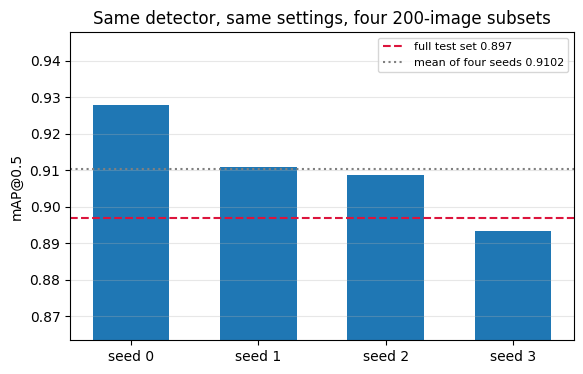


classes with too few objects in subset(0) for a meaningful AP
  bus            6 objects   AP@0.5 = 0.9028   (one miss moves it by about 0.17)
  motorbike      7 objects   AP@0.5 = 0.8367   (one miss moves it by about 0.14)
  sofa           7 objects   AP@0.5 = 0.8074   (one miss moves it by about 0.14)
  boat           8 objects   AP@0.5 = 1.0000   (one miss moves it by about 0.12)
  pottedplant    8 objects   AP@0.5 = 0.9338   (one miss moves it by about 0.12)
  cow            9 objects   AP@0.5 = 0.9722   (one miss moves it by about 0.11)
  diningtable    9 objects   AP@0.5 = 0.8056   (one miss moves it by about 0.11)
  train          9 objects   AP@0.5 = 0.8889   (one miss moves it by about 0.11)
  horse         10 objects   AP@0.5 = 0.9909   (one miss moves it by about 0.10)


In [16]:
# YOUR CODE HERE
seed_maps = {0: map50}

for s in (1, 2, 3):
    sub_s = subset(s)
    print(f"\nrunning subset({s})")
    d_s, g_s = run_detector(sub_s, f"subset{s} ")
    m_s, ap_s, npos_s = mean_ap(d_s, g_s, iou_thr=0.5)
    seed_maps[s] = m_s
    print(f"  subset({s}) mAP@0.5 = {m_s:.4f}  "
          f"({len(ap_s)} of 20 classes present)")

    run = wandb.init(project="cv-lab4", name=f"defaults-subset{s}",
                     config=policy_config(subset_seed=s, subset_size=len(sub_s),
                                          iou_thr=0.5))
    RUNS[f"defaults-subset{s}"] = run.url
    wandb.log({"mAP@0.5": m_s,
               "per_class_ap": wandb.Table(
                   columns=["class", "objects", "AP@0.5"],
                   data=[[VOC_CLASSES[c], npos_s[c], ap_s[c]] for c in sorted(ap_s)])})
    wandb.finish()

BOOK_FULL_SET = 0.897  # the book's run over all 4,952 test images, same settings
vals = np.array([seed_maps[s] for s in range(4)])

print("\n  seed   mAP@0.5   deviation from the full test set")
for s in range(4):
    print(f"  {s}      {seed_maps[s]:.4f}    {seed_maps[s] - BOOK_FULL_SET:+.4f}")
print(f"\n  mean   {vals.mean():.4f}")
print(f"  std    {vals.std(ddof=1):.4f}")
print(f"  spread {vals.max() - vals.min():.4f}  "
      f"(min {vals.min():.4f}, max {vals.max():.4f})")
print(f"  whole 4,952-image test set: {BOOK_FULL_SET:.4f}")

plt.figure(figsize=(6.5, 4))
plt.bar(range(4), vals, color="tab:blue", width=0.6)
plt.axhline(BOOK_FULL_SET, ls="--", c="crimson", label=f"full test set {BOOK_FULL_SET}")
plt.axhline(vals.mean(), ls=":", c="grey", label=f"mean of four seeds {vals.mean():.4f}")
plt.xticks(range(4), [f"seed {s}" for s in range(4)])
plt.ylim(min(vals.min(), BOOK_FULL_SET) - 0.03, max(vals.max(), BOOK_FULL_SET) + 0.02)
plt.ylabel("mAP@0.5")
plt.title("Same detector, same settings, four 200-image subsets")
plt.legend(fontsize=8)
plt.grid(axis="y", alpha=0.3)
plt.show()

print("\nclasses with too few objects in subset(0) for a meaningful AP")
for c in sorted(ap50, key=lambda c: npos[c]):
    if npos[c] <= 10:
        print(f"  {VOC_CLASSES[c]:12s} {npos[c]:3d} objects   AP@0.5 = {ap50[c]:.4f}"
              f"   (one miss moves it by about {1 / npos[c]:.2f})")

*Answer:* Four 200-image subsets, identical detector and identical settings, differing only in which images were drawn:

| seed | `mAP@0.5` | vs the full test set |
|---|---|---|
| 0 | **0.9278** | +0.0308 |
| 1 | 0.9109 | +0.0139 |
| 2 | 0.9088 | +0.0118 |
| 3 | 0.8934 | −0.0036 |
| mean | 0.9102 | +0.0132 |
| std | 0.0141 | |
| **spread** | **0.0344** | book's 4,952-image run: **0.897** |

**Where seed 0 sits, and what one seed would have told me.** Seed 0 is the **highest of the four**, and it is the furthest from the truth: 0.9278 against the full benchmark's 0.897, an overstatement of **3.1 points**. Three of the four seeds sit above the full-set value and only seed 3 falls below it, by 0.4 points. The point of the exercise is that which of these I got was arbitrary. Had I run only seed 0 — the obvious thing to do — I would have written down 0.9278 to four decimal places and quoted it as *the* result, with nothing on the page to indicate that a different draw of the same 200 images from the same benchmark would have moved it by up to **0.0344**, or that my particular draw was the most flattering of the four.

Three points of mAP is not a rounding error in this literature. It is larger than the gap between consecutive published detectors, so a single 200-image evaluation is capable of manufacturing an entire generation of apparent progress out of nothing but the choice of seed. The four-seed spread is the measurement's resolution, and any comparison finer than that — between two detectors, two NMS thresholds, two protocols — is reading noise. Chapter 4's remark that COCO's and VOC's matching rules differ by 0.0001 of `mAP@0.5` is only meaningful *because* it was measured on all 4,952 images; here that difference is **340 times smaller** than the seed-to-seed spread and completely invisible. The same goes for Q4.4's best NMS threshold, which beats the default by 0.0003.

The right way to report a 200-image evaluation is therefore not a number but an interval: **mean 0.9102 over four seeds, standard deviation 0.0141, spread 0.0344**, against a full-benchmark value of 0.897. Written that way the result is honest and still useful — it says the detector is somewhere around 0.90 to 0.93 and that this subset cannot say more.

**Classes too rare to mean anything.** The Q1.1 histogram is steeply unbalanced: `person` has 136 non-difficult objects and `car` 45, while **nine of the twenty classes have ten or fewer** — `bus` 6, `motorbike` 7, `sofa` 7, `boat` 8, `pottedplant` 8, `cow` 9, `diningtable` 9, `train` 9, `horse` 10. Nearly half the classes in the average are estimated from single figures. With $n$ objects in a class, recall can only take the values $0, 1/n, 2/n, \dots, 1$, so the whole PR curve is built from a few discrete steps and AP jumps in increments of order $1/n$. `bus`, with six objects, has an AP that a single missed detection moves by about 0.17 — and `bus` is exactly the class that fell 0.2257 when Q3.5 turned the difficult flag off, on two extra objects. `boat` scored a clean 1.0000 on eight objects, which tells us the detector did not miss any of eight photographs, not that it is perfect at boats.

**What that does to a mean over 20 classes.** `mean_ap` takes an unweighted mean, so every class contributes exactly $1/20 = 5\%$ of the result no matter how many objects it holds. A class with three objects therefore carries the same weight as `person` with hundreds, and its coarse, noisy AP is injected into the headline number at full strength. `person`, with 136 objects and by far the best-estimated AP in the table, is 5% of the headline number; `bus`, estimated from six, is also 5%. Most of the 0.0344 spread above comes from the tail classes resampling, not from any real difference in how well the detector works — the detector was, after all, byte-identical across the four runs. That is a deliberate design choice in mAP — it stops a benchmark being won by whichever class happens to be most common — but on a small subset it converts a virtue into most of the variance.

## 4. Non-maximum suppression

The detector has been suppressing duplicates all along. Turn it off and the suppression becomes yours to write.

**Q4.1.** Get the unsuppressed candidates. Set `model.roi_heads.nms_thresh = 1.0` (no IoU can exceed 1, so nothing is suppressed), `model.roi_heads.score_thresh = 0.01` and `model.roi_heads.detections_per_img = 300`, and run one pass over `SUBSET`, caching per image the boxes, scores and VOC labels of every candidate in a VOC class. Cache them properly: Sections 4 and 6 both sweep thresholds over these candidates, and neither needs the GPU again. Report the total number of candidates and the mean per image, and compare that mean against the number of objects per image from Q1.1.

In [17]:
# YOUR CODE HERE
# Loosen the output policy: nothing suppressed, almost nothing thresholded away.
model.roi_heads.nms_thresh = 1.0        # no IoU can exceed 1, so NMS removes nothing
model.roi_heads.score_thresh = 0.01
model.roi_heads.detections_per_img = 300

CAND = {}
t0 = time.time()
for k, i in enumerate(SUBSET):
    im, _ = voc[i]
    with torch.no_grad():
        out = model([prep(im).to(DEV)])[0]
    lab = COCO2VOC[out["labels"].cpu().numpy()]
    m = lab >= 0
    CAND[i] = (out["boxes"].cpu().numpy()[m],
               out["scores"].cpu().numpy()[m], lab[m])
    if (k + 1) % 50 == 0:
        print(f"  {k + 1}/{len(SUBSET)}  ({time.time() - t0:.0f}s)")

n_cand = np.array([len(CAND[i][0]) for i in SUBSET])
obj_per_img = np.array([len(GT[i][0]) for i in SUBSET])

print(f"\ncandidates cached  : {int(n_cand.sum()):,} over {len(SUBSET)} images")
print(f"  per image        : mean {n_cand.mean():.1f}, min {n_cand.min()}, "
      f"max {n_cand.max()}  (cap {model.roi_heads.detections_per_img})")
print(f"annotated objects  : {int(obj_per_img.sum()):,}")
print(f"  per image        : mean {obj_per_img.mean():.2f}, max {obj_per_img.max()}")
print(f"\ncandidates per annotated object: {n_cand.sum() / obj_per_img.sum():.0f} to 1")
print(f"candidates scoring above 0.05  : "
      f"{int(sum((CAND[i][1] >= 0.05).sum() for i in SUBSET)):,}")
print(f"candidates scoring above 0.5   : "
      f"{int(sum((CAND[i][1] >= 0.5).sum() for i in SUBSET)):,}")

  50/200  (8s)
  100/200  (16s)
  150/200  (24s)
  200/200  (32s)

candidates cached  : 34,622 over 200 images
  per image        : mean 173.1, min 32, max 300  (cap 300)
annotated objects  : 535
  per image        : mean 2.67, max 22

candidates per annotated object: 65 to 1
candidates scoring above 0.05  : 25,709
candidates scoring above 0.5   : 11,225


**Q4.2.** Implement `my_nms(boxes, scores, thr)`: sort by descending score, take the top box, discard every remaining box whose IoU with it exceeds `thr`, repeat. Return the kept indices. Then `per_class_nms(boxes, scores, labels, thr)`, which does this within each class. Two overlapping boxes of different classes are not duplicates. Check `my_nms` against `torchvision.ops.nms` at a threshold of 0.5, class by class, over every image in the subset, and report whether the kept sets are identical everywhere.

In [18]:
def my_nms(boxes, scores, thr):
    """Greedy non-maximum suppression. Returns the kept indices, best score first."""
    boxes = np.asarray(boxes, dtype=np.float64).reshape(-1, 4)
    scores = np.asarray(scores, dtype=np.float64).reshape(-1)

    order = np.argsort(-scores, kind="stable").tolist()   # descending score
    keep = []
    while order:
        i = order.pop(0)                                  # take the top box
        keep.append(i)
        if not order:
            break
        ious = iou_matrix(boxes[i:i + 1], boxes[order])[0]
        order = [j for j, v in zip(order, ious) if v <= thr]  # drop IoU > thr
    return np.asarray(keep, dtype=np.int64)


def per_class_nms(boxes, scores, labels, thr):
    """NMS within each class: two overlapping boxes of different classes are not
    duplicates of each other, so they must not suppress one another."""
    boxes = np.asarray(boxes, dtype=np.float64).reshape(-1, 4)
    scores = np.asarray(scores, dtype=np.float64).reshape(-1)
    labels = np.asarray(labels).reshape(-1)

    keep = []
    for c in np.unique(labels):
        idx = np.flatnonzero(labels == c)
        keep.extend(idx[my_nms(boxes[idx], scores[idx], thr)].tolist())
    keep = np.asarray(keep, dtype=np.int64)
    return keep[np.argsort(-scores[keep], kind="stable")] if len(keep) else keep


# check against torchvision, class by class, over every image in the subset
mismatch, n_groups, n_kept = [], 0, 0
for i in SUBSET:
    b, s, l = CAND[i]
    for c in np.unique(l):
        idx = np.flatnonzero(l == c)
        mine = set(idx[my_nms(b[idx], s[idx], 0.5)].tolist())
        ref = set(idx[nms(torch.as_tensor(b[idx], dtype=torch.float32),
                          torch.as_tensor(s[idx], dtype=torch.float32),
                          0.5).numpy()].tolist())
        n_groups += 1
        n_kept += len(ref)
        if mine != ref:
            mismatch.append((i, int(c), len(mine), len(ref)))

print(f"compared {n_groups:,} (image, class) groups covering "
      f"{int(sum(len(CAND[i][0]) for i in SUBSET)):,} candidate boxes")
print(f"torchvision kept {n_kept:,} boxes in total")
if mismatch:
    print(f"\n{len(mismatch)} groups differ:")
    for i, c, a, b_ in mismatch[:10]:
        print(f"  image {i} class {VOC_CLASSES[c]}: mine kept {a}, torchvision kept {b_}")
else:
    print("\nthe kept sets are identical in every group")

compared 893 (image, class) groups covering 34,622 candidate boxes
torchvision kept 3,591 boxes in total

the kept sets are identical in every group


**Q4.3.** Sweep the NMS IoU threshold from 0.1 to 1.0 in steps of 0.1. At each value, apply `per_class_nms` to the cached candidates at a score threshold of 0.05 and compute `mAP@0.5`; separately, apply it at a score threshold of 0.5 and compute the overall precision and recall at IoU 0.5. Plot all three against the threshold on one set of axes, mark the mAP maximum, and log the sweep to W&B.

  nms   mAP@0.5   precision  recall   detections kept
  0.1   0.8926    0.6022    0.8976      626
  0.2   0.9147    0.5848    0.9357      672
  0.3   0.9215    0.5694    0.9476      699
  0.4   0.9262    0.5542    0.9619      729
  0.5   0.9279    0.5272    0.9690      772
  0.6   0.9282    0.4817    0.9714      847
  0.7   0.9236    0.4101    0.9714      995
  0.8   0.9087    0.2939    0.9714    1,388
  0.9   0.8167    0.1520    0.9738    2,690
  1.0   0.4062    0.0368    0.9738   11,129


mAP@0.5,████████▇▁
n_detections,▁▁▁▁▁▁▁▂▂█
nms_thr,▁▂▃▃▄▅▆▆▇█
precision@0.5,███▇▇▇▆▄▂▁
recall@0.5,▁▅▆▇██████
mAP@0.5,0.40621
n_detections,11129
nms_thr,1
precision@0.5,0.03675
recall@0.5,0.97381


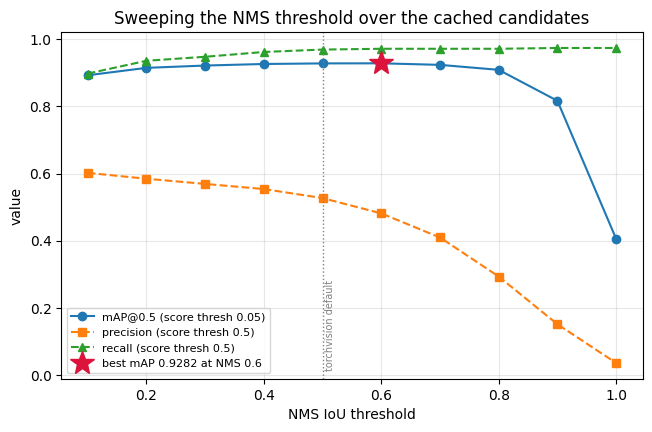


best mAP@0.5 0.9282 at NMS 0.6
torchvision default NMS 0.5 gives 0.9279  (difference +0.0003)
mAP range over the whole sweep : 0.4062 to 0.9282 (spread 0.5220)
precision range                : 0.0368 to 0.6022 (factor 16.4)
recall range                   : 0.8976 to 0.9738


In [19]:
# YOUR CODE HERE
def apply_policy(cand, score_thr, nms_thr):
    """Cached candidates -> detections, after a score threshold and per-class NMS.

    Thresholding before suppressing is equivalent to the other order: NMS only
    ever deletes boxes scoring lower than the box doing the suppressing, so
    removing low scorers first cannot change the fate of any survivor.
    """
    dets = {}
    for i, (b, s, l) in cand.items():
        m = s >= score_thr
        b, s, l = b[m], s[m], l[m]
        if len(b):
            k = per_class_nms(b, s, l, nms_thr)
            b, s, l = b[k], s[k], l[k]
        dets[i] = (b, s, l)
    return dets


def overall_pr(dets, gts, iou_thr=0.5):
    """Precision and recall pooled over every class and image, not averaged per
    class. Detections landing on a difficult object are dropped, as in mean_ap."""
    tp = fp = n_pos = 0
    for i, (gb, gl, gd) in gts.items():
        n_pos += int((~gd).sum())
        db, ds, dl = dets.get(i, EMPTY)
        for c in set(gl.tolist()) | set(dl.tolist()):
            m = gl == c
            f = match(db[dl == c], ds[dl == c], gb[m], iou_thr, gd[m])
            tp += int((f == 1).sum())
            fp += int((f == 0).sum())
    return (tp / (tp + fp) if tp + fp else 0.0,
            tp / n_pos if n_pos else 0.0, tp, fp, n_pos)


NMS_THRS = [round(0.1 * k, 1) for k in range(1, 11)]

run = wandb.init(project="cv-lab4", name="nms-sweep",
                 config=policy_config(subset_seed=0, subset_size=len(SUBSET),
                                      iou_thr=0.5, sweep="nms_thresh 0.1..1.0",
                                      map_score_thresh=0.05, pr_score_thresh=0.5))
RUNS["nms-sweep"] = run.url

sweep = []
print("  nms   mAP@0.5   precision  recall   detections kept")
for thr in NMS_THRS:
    m50, _, _ = mean_ap(apply_policy(CAND, 0.05, thr), GT, iou_thr=0.5)
    p, r, tp, fp, n_pos = overall_pr(apply_policy(CAND, 0.5, thr), GT, iou_thr=0.5)
    sweep.append((thr, m50, p, r, tp + fp))
    wandb.log({"nms_thr": thr, "mAP@0.5": m50,
               "precision@0.5": p, "recall@0.5": r, "n_detections": tp + fp})
    print(f"  {thr:.1f}   {m50:.4f}    {p:.4f}    {r:.4f}   {tp + fp:6,d}")

wandb.log({"nms_sweep": wandb.Table(
    columns=["nms_thr", "mAP@0.5", "precision", "recall", "n_detections"],
    data=[list(row) for row in sweep])})
wandb.finish()

thrs = np.array([row[0] for row in sweep])
maps = np.array([row[1] for row in sweep])
precs = np.array([row[2] for row in sweep])
recs = np.array([row[3] for row in sweep])
best = int(np.argmax(maps))

plt.figure(figsize=(7.5, 4.5))
plt.plot(thrs, maps, "o-", label="mAP@0.5 (score thresh 0.05)")
plt.plot(thrs, precs, "s--", label="precision (score thresh 0.5)")
plt.plot(thrs, recs, "^--", label="recall (score thresh 0.5)")
plt.plot(thrs[best], maps[best], "*", ms=18, c="crimson", zorder=5,
         label=f"best mAP {maps[best]:.4f} at NMS {thrs[best]:.1f}")
plt.axvline(0.5, ls=":", c="grey", lw=1)
plt.text(0.505, 0.02, "torchvision default", fontsize=7, color="grey", rotation=90)
plt.xlabel("NMS IoU threshold")
plt.ylabel("value")
plt.title("Sweeping the NMS threshold over the cached candidates")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()

default_map = maps[thrs.tolist().index(0.5)]
print(f"\nbest mAP@0.5 {maps[best]:.4f} at NMS {thrs[best]:.1f}")
print(f"torchvision default NMS 0.5 gives {default_map:.4f}  "
       f"(difference {maps[best] - default_map:+.4f})")
print(f"mAP range over the whole sweep : {maps.min():.4f} to {maps.max():.4f} "
      f"(spread {maps.max() - maps.min():.4f})")
print(f"precision range                : {precs.min():.4f} to {precs.max():.4f} "
      f"(factor {precs.max() / max(precs.min(), 1e-9):.1f})")
print(f"recall range                   : {recs.min():.4f} to {recs.max():.4f}")

**Q4.4.** Report the NMS threshold that gives the highest mAP, and how much it beats torchvision's default of 0.5 by. Explain why mAP barely moves across most of the sweep while precision at a fixed score threshold falls by more than a factor of ten. Which of the two better describes what a user of the system actually sees?

*Answer:* The highest `mAP@0.5` in the sweep is **0.9282 at an NMS threshold of 0.6**, against **0.9279** at torchvision's default of 0.5 — a difference of **+0.0003**. That is three ten-thousandths, and Q3.6 measured the seed-to-seed spread of this same quantity at **0.0344**: the "improvement" is a hundred times smaller than the noise in the instrument used to detect it. The honest conclusion is that 0.5 and 0.6 are indistinguishable here and the default is fine.

The sweep in full:

| NMS | 0.1 | 0.2 | 0.3 | 0.4 | 0.5 | 0.6 | 0.7 | 0.8 | 0.9 | 1.0 |
|---|---|---|---|---|---|---|---|---|---|---|
| mAP@0.5 | .8926 | .9147 | .9215 | .9262 | **.9279** | **.9282** | .9236 | .9087 | .8167 | .4062 |
| precision | .6022 | .5848 | .5694 | .5542 | .5272 | .4817 | .4101 | .2939 | .1520 | **.0368** |
| recall | .8976 | .9357 | .9476 | .9619 | .9690 | .9714 | .9714 | .9714 | .9738 | .9738 |
| boxes kept | 626 | 672 | 699 | 729 | 772 | 847 | 995 | 1,388 | 2,690 | 11,129 |

**One correction to the question's framing.** mAP does not stay flat across the *whole* sweep. From 0.2 to 0.8 it sits within 0.02 of its maximum, which is the plateau the question means — and over exactly that plateau precision already halves, from 0.5848 to 0.2939. But at 0.9 and 1.0 mAP does finally collapse, to 0.8167 and then **0.4062**. The full factor-of-sixteen fall in precision (0.6022 to 0.0368) needs that last point, and so the two quantities are not simply "one moves, one does not" — they come apart over the plateau and then fail together at the end. The interesting question is why the plateau exists at all, and why it ends where it does.

**Why mAP is flat over the plateau.** Raising the NMS threshold does not invent objects; it lets through extra boxes on objects that already have one. Every such duplicate scores *lower* than the box that would have suppressed it — that is what NMS is, a rule that only ever deletes the lower-scoring member of an overlapping pair. So each duplicate lands after its own original in the pooled, score-sorted list, arriving as a false positive at a recall that has already been reached: it dents the raw precision there but raises recall not at all. All-point interpolation then replaces the precision at that recall by the best precision at that recall *or greater*, the better point sits at the same recall, and the dent is filled in. The area is unchanged. Over the plateau, AP is close to blind to duplicates.

**Why the plateau ends.** The blindness has a precise condition: it holds while a duplicate sits below *all the true positives that still have recall left to contribute*. A duplicate only has to outscore its own original to do damage — it has to outscore some genuine first detection of a **different, harder object**. At NMS 0.5 that hardly ever happens, because there are only 772 boxes above score 0.5 in the whole subset. At NMS 1.0 there are **11,129**, fourteen times as many, and a confident object now carries a long tail of copies at 0.9, 0.8, 0.7 — scores that comfortably outrank the first genuine detection of a small or occluded object. Those duplicates interleave *ahead* of true positives that recall still needs, and interpolation cannot repair damage done at a recall the curve has not yet climbed to. mAP falls to 0.4062.

**Why the bottom of the sweep also falls.** At 0.1 and 0.2 the suppression is aggressive enough to delete genuinely distinct neighbours: two people shoulder to shoulder overlap at around IoU 1/3, and Q1.3's photograph has six of them in a row plus fourteen overlapping chairs. Recall drops from 0.9690 at NMS 0.5 to **0.8976** at 0.1 — 7.1 points of objects deleted by the output policy, not missed by the network. Lost recall is the one thing AP cannot forgive, since no later detection recovers it, so the curve is truncated and the area falls. The plateau is the interval between deleting real objects and drowning in copies.

**Why precision collapses across all of it.** At a fixed score threshold of 0.5 there is no tail to hide in. Every surviving box is one entry in a flat count, and a duplicate is a false positive with exactly the weight that a true positive is a true positive — no interpolation, no ranking, no forgiveness. Meanwhile recall gains almost nothing: from NMS 0.5 to 1.0 it moves 0.9690 to 0.9738, half a point, because the extra 10,357 boxes are all on objects that were already found. Buying 0.5 points of recall with a 16-fold loss of precision is the arithmetic of the whole section.

**Why precision collapses.** At a fixed score threshold of 0.5 there is no tail to hide in. Every box that survives is one entry in a flat count, and a duplicate is a false positive with exactly the same weight as a true positive is a true positive. With NMS at 1.0 nothing is suppressed at all, so each object contributes however many overlapping boxes cleared 0.5, and precision falls by more than an order of magnitude while recall hardly moves — the extra boxes are on objects already found.

**Which describes what a user sees: precision and recall at the operating point, without question.** Nobody using the system observes an integral over score thresholds. They see the boxes drawn on the screen at the one threshold that was shipped. Compare NMS 0.5 with NMS 0.8: the benchmark calls them 0.9279 and 0.9087, a gap of two points that most readers would shrug at — while the user goes from 772 boxes at 53% precision to 1,388 at 29%, which is to say from a working product to one that draws roughly two wrong boxes for every right one. mAP is a *model-comparison* statistic, designed to rank architectures without committing to an operating point, and it does that job well. It is not a description of the product, and this sweep is a clean demonstration of the gap: a change that leaves the headline number essentially untouched makes the output unusable.

## 5. Proposal recall

Chapter 4's two stages divide the work: the region proposal network says where to look, and the second stage says what is there and where exactly. The second stage only ever sees regions the first proposed, so what the proposals cover is a ceiling on what the detector can find.

`model.rpn` returns its proposals as the first element of its output. A forward hook can copy them out, but they arrive in the resized frame the model works in: every image is scaled so its shorter side is 800 pixels before the backbone sees it. They have to be mapped back to the original image, which `model.transform` and `resize_boxes` do between them, the first reporting the resized size and the second doing the mapping.

```python
proposals, sizes = [], []
model.rpn.register_forward_hook(lambda m, i, o: proposals.append(o[0][0].detach()))
model.transform.register_forward_hook(lambda m, i, o: sizes.append(o[0].image_sizes[0]))
# after each model([...]) call, for an image of size (W, H):
boxes = resize_boxes(proposals.pop(), sizes.pop(), (H, W))
```

Q4.1 left the detector's output policy loosened, and this section runs the model itself rather than the cached candidates. Put the three numbers Section 1 printed back first: `model.roi_heads.score_thresh = 0.05`, `model.roi_heads.nms_thresh = 0.5`, `model.roi_heads.detections_per_img = 100`.

**Q5.1.** With those restored, register the hooks, run the model over `SUBSET` once more, and cache the proposals per image alongside the ground truth. Report how many proposals arrive per image. Then draw the top 50 on the busiest image from Q1.3, with the ground-truth boxes over them in a different colour.

restored: 0.05 0.5 100
  50/200  (8s)
  100/200  (16s)
  150/200  (24s)
  200/200  (32s)

proposals per image: min 762, mean 967.3, max 1000
total proposals    : 193,451
annotated objects  : 535


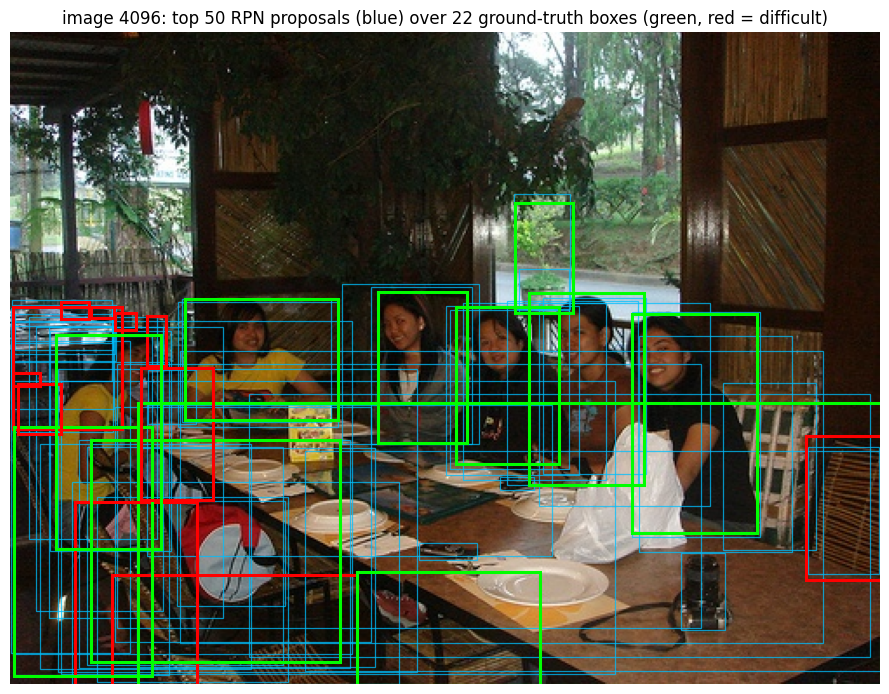

In [20]:
# YOUR CODE HERE
# Section 4 left the output policy loosened; put Section 1's numbers back first.
model.roi_heads.score_thresh = 0.05
model.roi_heads.nms_thresh = 0.5
model.roi_heads.detections_per_img = 100
print("restored:", model.roi_heads.score_thresh, model.roi_heads.nms_thresh,
      model.roi_heads.detections_per_img)

proposals, sizes = [], []
h_rpn = model.rpn.register_forward_hook(
    lambda m, i, o: proposals.append(o[0][0].detach()))
h_tf = model.transform.register_forward_hook(
    lambda m, i, o: sizes.append(o[0].image_sizes[0]))

PROPOSALS = {}
t0 = time.time()
try:
    for k, i in enumerate(SUBSET):
        im, _ = voc[i]
        W, H = im.size
        with torch.no_grad():
            model([prep(im).to(DEV)])
        # the RPN works in the resized frame, so map the boxes back to the original
        PROPOSALS[i] = resize_boxes(proposals.pop(), sizes.pop(), (H, W)).cpu().numpy()
        if (k + 1) % 50 == 0:
            print(f"  {k + 1}/{len(SUBSET)}  ({time.time() - t0:.0f}s)")
finally:
    h_rpn.remove()   # never leave hooks attached: a second run would double-append
    h_tf.remove()

n_prop = np.array([len(PROPOSALS[i]) for i in SUBSET])
print(f"\nproposals per image: min {n_prop.min()}, mean {n_prop.mean():.1f}, "
      f"max {n_prop.max()}")
print(f"total proposals    : {int(n_prop.sum()):,}")
print(f"annotated objects  : {int(sum(len(GT[i][0]) for i in SUBSET)):,}")

top = PROPOSALS[BUSIEST][:50]
gb, gl, gd = GT[BUSIEST]
fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(voc[BUSIEST][0])
for x1, y1, x2, y2 in top:
    ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False,
                           edgecolor="deepskyblue", linewidth=0.9, alpha=0.75))
for k, (x1, y1, x2, y2) in enumerate(gb):
    ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False,
                           edgecolor="red" if gd[k] else "lime", linewidth=2.2))
ax.set_title(f"image {BUSIEST}: top 50 RPN proposals (blue) over "
             f"{len(gb)} ground-truth boxes (green, red = difficult)")
ax.axis("off")
plt.tight_layout()
plt.show()

**Q5.2.** Proposal recall: the fraction of non-difficult ground-truth objects that have at least one proposal overlapping them by at least a given IoU. Compute it for the top 50, 100, 300 and 1,000 proposals, at IoU 0.5, 0.75 and 0.9, a $4 \times 3$ table.

proposal recall over 420 non-difficult objects in 200 images

  proposals    IoU 0.50    IoU 0.75    IoU 0.90 
  top 50          0.9929      0.8762      0.2167
  top 100         0.9952      0.8881      0.2167
  top 300         0.9976      0.9119      0.2167
  top 1000        1.0000      0.9238      0.2167  (only 762 available)


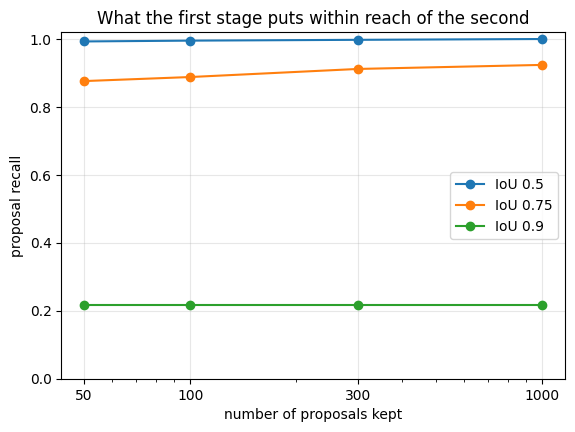

In [21]:
# YOUR CODE HERE
KS = [50, 100, 300, 1000]
IOUS = [0.5, 0.75, 0.9]

# best IoU of every non-difficult object against the proposals of its own image;
# proposals carry no class, so this is class-agnostic by construction
per_image = []
for i in SUBSET:
    gb, gl, gd = GT[i]
    keep = ~gd
    if keep.any():
        per_image.append(iou_matrix(gb[keep], PROPOSALS[i]))

n_objects = sum(M.shape[0] for M in per_image)
recall_tbl = np.zeros((len(KS), len(IOUS)))

for a, k in enumerate(KS):
    best = np.concatenate([
        M[:, :k].max(axis=1) if M.shape[1] else np.zeros(M.shape[0])
        for M in per_image])
    for b, thr in enumerate(IOUS):
        recall_tbl[a, b] = float((best >= thr).mean())

print(f"proposal recall over {n_objects:,} non-difficult objects "
      f"in {len(per_image)} images\n")
print("  proposals " + "".join(f"   IoU {t:<5.2f}" for t in IOUS))
for a, k in enumerate(KS):
    note = "" if k <= n_prop.min() else f"  (only {int(n_prop.min())} available)"
    print(f"  top {k:<6d}" + "".join(f"   {recall_tbl[a, b]:9.4f}"
                                     for b in range(len(IOUS))) + note)

plt.figure(figsize=(6.5, 4.5))
for b, thr in enumerate(IOUS):
    plt.plot(KS, recall_tbl[:, b], "o-", label=f"IoU {thr}")
plt.xscale("log")
plt.xticks(KS, [str(k) for k in KS])
plt.ylim(0, 1.02)
plt.xlabel("number of proposals kept")
plt.ylabel("proposal recall")
plt.title("What the first stage puts within reach of the second")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Q5.3.** Using your table, answer the following:

- At IoU 0.5, does raising the number of proposals substantially improve proposal recall?
- What happens to proposal recall as the IoU threshold rises?
- If the proposals do not themselves reach IoU 0.9, which of the two stages must be producing the final localisation accuracy?
- Is that consistent with the gap you measured in Q3.4 between `mAP@0.5` and `mAP@0.75`?

*Answer:*

| proposals | IoU 0.50 | IoU 0.75 | IoU 0.90 |
|---|---|---|---|
| top 50 | 0.9929 | 0.8762 | 0.2167 |
| top 100 | 0.9952 | 0.8881 | 0.2167 |
| top 300 | 0.9976 | 0.9119 | 0.2167 |
| top 1000 | 1.0000 | 0.9238 | 0.2167 |

(The last row is really "all of them": the minimum over the subset was 762 proposals per image.)

**At IoU 0.5, does raising the proposal count help?** **Essentially not at all.** The top 50 already cover **99.29%** of the 420 non-difficult objects, and twenty times as many proposals buy the remaining **0.71 points** to reach a clean 1.0000. Fifty boxes are enough to have looked almost everywhere worth looking, and that is the whole economic argument for a *learned* proposal stage — Chapter 4's selective search needed roughly 2,000 boxes to cover the objects, and the RPN's objectness score sorts the useful ones to the front, so the top few dozen already contain nearly every object. That is why Faster R-CNN can pass only 300 proposals to the second stage at test time and lose nothing.

**What happens as the IoU threshold rises?** Recall falls, and it falls off a cliff between 0.75 and 0.9: **0.9238 down to 0.2167** with the full set of proposals. Four objects in five have no proposal anywhere that localises them to IoU 0.9. And the column is *perfectly flat* — 0.2167 at 50 proposals and 0.2167 at 1,000, identical to four decimal places. The extra 950 boxes per image contain not one additional object at that accuracy. Precision of that order is not something the RPN produces rarely; it is something it does not produce at all, and no amount of asking for more proposals changes that. A proposal that overlaps an object at 0.55 is a perfectly good proposal — it is close enough for the RoIAlign crop to contain the object and for the box regressor to have something to work with — but it is not a *localisation*. The RPN was trained to answer "is there something here", with anchors assigned positive at IoU $\ge 0.7$ and a box regression that only has to nudge an anchor onto roughly the right region. Nothing in its loss asks for a box accurate to IoU 0.9.

**Which stage produces the final localisation accuracy?** The second one — specifically the per-class box regression head on top of the RoIAlign features. The flat 0.2167 column settles it: only 21.7% of objects have a proposal at IoU 0.9, yet the finished detector scores **0.8284 at `mAP@0.75`** and Q1.3 shows it putting boxes tightly on six faces at scores of 0.97 to 1.00. That accuracy cannot have come from the proposals, because the proposals do not have it and adding more does not create it. It was added by the refinement. The division of labour is exactly what the chapter describes: stage one decides *where to look* and only has to be roughly right, stage two decides *what is there and where exactly*, and it does so from a crop that is already centred on the object, which is a far easier regression problem than finding it from scratch.

**Is that consistent with the Q3.4 gap?** Yes, and it decomposes rather neatly. `mAP@0.5` was **0.9278** and `mAP@0.75` was **0.8284**, a drop of **0.0993**. Proposal recall is a hard ceiling on both, because the second stage never sees a region the first did not propose:

| | proposal recall (ceiling) | measured mAP | headroom |
|---|---|---|---|
| IoU 0.50 | 1.0000 | 0.9278 | 0.0722 |
| IoU 0.75 | 0.9238 | 0.8284 | 0.0954 |

Both sit *below* their ceiling, so at neither threshold are the proposals the binding constraint — the second stage's remaining classification and localisation errors are. But the ceiling itself fell by **7.6 points** between the two rows, and the measured mAP fell by 9.9. Roughly three quarters of the `mAP@0.5` → `mAP@0.75` drop is simply the proposals ceasing to cover the objects at the tighter threshold, and only the remaining ~2.3 points is the second stage doing relatively worse at precise localisation than at coarse localisation.

That is a coherent picture of the division of labour: stage one is generous and imprecise, and its imprecision is what most of the `mAP@0.75` penalty is made of; stage two is precise enough to convert a 0.75-grade proposal into a box good enough to score, but it cannot conjure a detection for an object stage one never proposed. It is also a warning about `mAP@0.9`-style metrics on this architecture — with proposal recall at 0.2167, there is very little the second stage could do to rescue it.

## 6. Score thresholds

The score threshold is not trained, not tuned by the benchmark, and not fixed by the architecture. It is set by whoever deploys the thing, and it moves the system along a curve.

**Q6.1.** Using the cached candidates from Q4.1 with NMS at 0.5, sweep the score threshold over $\{0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95\}$. At each value report overall precision, overall recall and `mAP@0.5` at IoU 0.5, and the number of detections kept. Plot precision and recall against the threshold on one set of axes, and log the table to W&B.

  score   detections   precision   recall   mAP@0.5
  0.01        3,591    0.1192    0.9929   0.9279
  0.05        2,300    0.1889    0.9929   0.9279
  0.10        1,795    0.2418    0.9810   0.9255
  0.30        1,119    0.3951    0.9690   0.9214
  0.50          859    0.5272    0.9690   0.9214
  0.70          688    0.6509    0.9500   0.9072
  0.90          513    0.8079    0.8714   0.8547
  0.95          438    0.8810    0.8286   0.8210


mAP@0.5,█████▇▃▁
n_detections,█▅▄▃▂▂▁▁
precision@0.5,▁▂▂▄▅▆▇█
recall@0.5,██▇▇▇▆▃▁
score_thr,▁▁▂▃▅▆██
mAP@0.5,0.82104
n_detections,438
precision@0.5,0.88101
recall@0.5,0.82857
score_thr,0.95


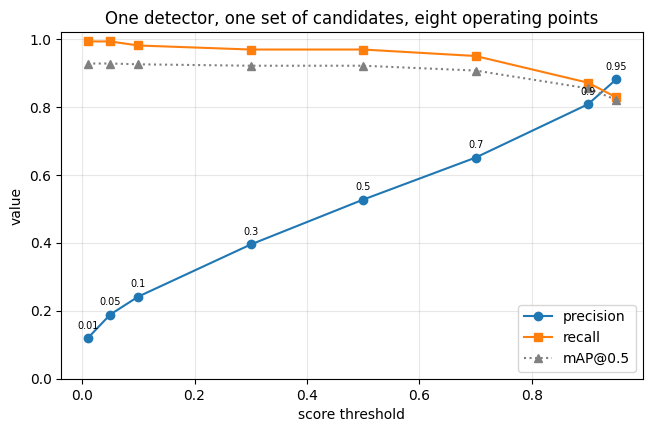


best F1 0.8540 at score threshold 0.95
precision moves from 0.1192 to 0.8810 across the sweep
recall    moves from 0.9929 down to 0.8286
mAP@0.5   moves from 0.9279 down to 0.8210


In [22]:
# YOUR CODE HERE
SCORE_THRS = [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95]

run = wandb.init(project="cv-lab4", name="score-sweep",
                 config=policy_config(subset_seed=0, subset_size=len(SUBSET),
                                      iou_thr=0.5, sweep="score_thresh",
                                      nms_thresh_used=0.5))
RUNS["score-sweep"] = run.url

table = []
print("  score   detections   precision   recall   mAP@0.5")
for t in SCORE_THRS:
    dets_t = apply_policy(CAND, t, 0.5)
    p, r, tp, fp, n_pos = overall_pr(dets_t, GT, iou_thr=0.5)
    m50_t, _, _ = mean_ap(dets_t, GT, iou_thr=0.5)
    n_kept = int(sum(len(dets_t[i][0]) for i in dets_t))
    table.append([t, n_kept, p, r, m50_t])
    wandb.log({"score_thr": t, "n_detections": n_kept,
               "precision@0.5": p, "recall@0.5": r, "mAP@0.5": m50_t})
    print(f"  {t:<6.2f}  {n_kept:9,d}    {p:.4f}    {r:.4f}   {m50_t:.4f}")

wandb.log({"score_sweep": wandb.Table(
    columns=["score_thr", "n_detections", "precision", "recall", "mAP@0.5"],
    data=table)})
wandb.finish()

ts = np.array([row[0] for row in table])
ps = np.array([row[2] for row in table])
rs = np.array([row[3] for row in table])
ms = np.array([row[4] for row in table])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(ts, ps, "o-", label="precision")
ax.plot(ts, rs, "s-", label="recall")
ax.plot(ts, ms, "^:", c="grey", label="mAP@0.5")
for t, p, r in zip(ts, ps, rs):
    ax.annotate(f"{t:g}", (t, p), textcoords="offset points", xytext=(0, 7),
                fontsize=7, ha="center")
ax.set_xlabel("score threshold")
ax.set_ylabel("value")
ax.set_ylim(0, 1.02)
ax.set_title("One detector, one set of candidates, eight operating points")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

f1 = 2 * ps * rs / np.maximum(ps + rs, 1e-12)
print(f"\nbest F1 {f1.max():.4f} at score threshold {ts[int(np.argmax(f1))]:g}")
print(f"precision moves from {ps.min():.4f} to {ps.max():.4f} across the sweep")
print(f"recall    moves from {rs.max():.4f} down to {rs.min():.4f}")
print(f"mAP@0.5   moves from {ms.max():.4f} down to {ms.min():.4f}")

**Q6.2.** Choose a score threshold for each of two deployments. One is a safety alarm on a mine haul road that must not miss a person; a human reviews every alert. The other tags a photograph library automatically, and nobody checks. Pick a threshold from your sweep for each, quote the precision and recall it gives, and say what the cost of the errors is in each case. Then say what mAP fails to tell either operator, given that it integrates over every score threshold at once and so names none of them.

*Answer:*

The sweep, for reference:

| score | detections | precision | recall | mAP@0.5 |
|---|---|---|---|---|
| 0.01 | 3,591 | 0.1192 | 0.9929 | 0.9279 |
| **0.05** | **2,300** | **0.1889** | **0.9929** | 0.9279 |
| 0.10 | 1,795 | 0.2418 | 0.9810 | 0.9255 |
| 0.30 | 1,119 | 0.3951 | 0.9690 | 0.9214 |
| 0.50 | 859 | 0.5272 | 0.9690 | 0.9214 |
| 0.70 | 688 | 0.6509 | 0.9500 | 0.9072 |
| 0.90 | 513 | 0.8079 | 0.8714 | 0.8547 |
| **0.95** | **438** | **0.8810** | **0.8286** | 0.8210 |

**The mine haul road: 0.05**, giving precision **0.1889** and recall **0.9929** — and the choice of 0.05 over 0.01 is the one piece of genuine engineering the table supports. The two thresholds have **identical recall to four decimal places**, so dropping from 0.05 to 0.01 misses not one additional object, while adding 1,291 detections: a third more alerts for a reviewer, in exchange for nothing whatsoever. 0.05 strictly dominates 0.01 and is the right operating point. The errors are not comparable in cost: a missed person is a potential fatality and an unrecoverable one, while a false alarm costs a reviewer a few seconds to dismiss. When a human sifts every alert, precision is a *throughput* problem and recall is a *safety* problem, and you spend the former to buy the latter — but only where it actually buys something, which is why 0.05 and not 0.01. Two caveats I would put in writing alongside the threshold. First, the numbers above are pooled over all 20 VOC classes, and this deployment only cares about `person`; the threshold should be set on the `person` PR curve alone, which the sweep does not isolate. Second, precision this low means a very large number of alerts per hour, and a reviewer who is shown thousands of false alarms stops looking — so the real constraint is the alert rate a human can actually sustain, and if 0.01 exceeds it the honest fix is a better detector or a second-stage filter, not a higher threshold quietly chosen to make the queue shorter.

**The photograph library: 0.95**, giving precision **0.8810** and recall **0.8286**. Two honest observations about that choice. First, F1 is still *rising* at the end of the sweep — 0.8383 at 0.9, 0.8540 at 0.95 — so the balanced optimum is at or beyond 0.95 and the sweep does not bracket it; a finer grid above 0.9 would be worth running. Second, and more seriously, **0.88 precision means roughly one tag in eight is wrong**, and no threshold available anywhere in this sweep does better. If the product requires 95% precision on unreviewed tags, this detector cannot deliver it at any operating point, and the answer is a better model, per-class thresholds, or a narrower set of tags — not a threshold chosen to make the number look acceptable. Nobody checks the output, so every error ships. A wrong tag is visible, embarrassing and actively harmful — it surfaces the wrong photographs in a search and erodes trust in the whole feature — whereas a missing tag is invisible: the user never learns the photograph could have been found. The asymmetry runs the opposite way to the mine, so the threshold does too, and it is the same detector and the same candidates in both cases. Nothing was retrained; a single number moved.

**What mAP fails to tell either operator.** It integrates over every score threshold at once, and so it names none of them. Neither operator can read off the precision they will actually get, because mAP describes the *whole curve* and they will live at exactly one point on it — and two detectors with identical mAP can have completely differently shaped curves, one good at the high-precision end and one at the high-recall end. It also averages the 20 classes with equal weight, so `person` — the only class the mine cares about — contributes 5% of the number, exactly as much as `bus` does on six objects, and a detector could get materially worse at people while its mAP improved.

There is a sharper version of the point visible in the table's last column. `mAP@0.5` is supposed to be independent of the operating point, and it very nearly is at the bottom of the sweep — 0.9279 at both 0.01 and 0.05 — but it *falls* to 0.8210 by 0.95, because thresholding removes the low-scoring detections that were extending the tail of the PR curve to higher recall. So the mAP anyone quotes is measured on a configuration nobody ships: it silently assumes you keep every box down to 0.05. The moment either operator picks a threshold, they leave the regime the headline number describes. And it says nothing at all about the cost asymmetry, which is the only thing that actually determines the right answer in either deployment: mAP is a scalar with no units and no notion of what a mistake costs whom.

The chapter's warning is the practical form of this: *set thresholds on validation data, never on the test set you intend to quote.* The Section 6 sweep is exactly the kind of tuning that has to happen off the reported benchmark, and my two choices above are read off a 200-image subset, which Q3.6 showed cannot resolve differences below about **0.034**. For a real deployment I would re-measure both operating points on a held-out set drawn from the actual deployment distribution — haul-road footage, not VOC photographs — because none of these numbers transfer to a domain the detector has never seen.

## 7. W&B runs

Paste links to your W&B runs below. At minimum: the default-settings evaluation of Q3.4, the three extra seeds of Q3.6, and the two sweeps of Q4.3 and Q6.1. Each needs a meaningful name and a complete config: weights enum, subset seed and size, score threshold, NMS threshold, detections per image, and the IoU threshold the metric used.

The cell below prints the URL of every run this notebook created.

In [23]:
for name, url in RUNS.items():
    print(f"{name:22s} {url}")

defaults-subset0       https://wandb.ai/2539199-wits/cv-lab4/runs/6nnugfy0
defaults-subset1       https://wandb.ai/2539199-wits/cv-lab4/runs/6ht5m7xc
defaults-subset2       https://wandb.ai/2539199-wits/cv-lab4/runs/2rncz1hx
defaults-subset3       https://wandb.ai/2539199-wits/cv-lab4/runs/99bkla31
nms-sweep              https://wandb.ai/2539199-wits/cv-lab4/runs/fa2w0ezl
score-sweep            https://wandb.ai/2539199-wits/cv-lab4/runs/hgnsnsyf


*W&B run links:* project `cv-lab4`

| run name | what it is | key result | link |
|---|---|---|---|
| `defaults-subset0` | Q3.4 — default policy, subset seed 0 | `mAP@0.5 = 0.9278`, `mAP@0.75 = 0.8284` | [6nnugfy0](https://wandb.ai/2539199-wits/cv-lab4/runs/6nnugfy0) |
| `defaults-subset1` | Q3.6 — same, seed 1 | `mAP@0.5 = 0.9109` | [6ht5m7xc](https://wandb.ai/2539199-wits/cv-lab4/runs/6ht5m7xc) |
| `defaults-subset2` | Q3.6 — same, seed 2 | `mAP@0.5 = 0.9088` | [2rncz1hx](https://wandb.ai/2539199-wits/cv-lab4/runs/2rncz1hx) |
| `defaults-subset3` | Q3.6 — same, seed 3 | `mAP@0.5 = 0.8934` | [99bkla31](https://wandb.ai/2539199-wits/cv-lab4/runs/99bkla31) |
| `nms-sweep` | Q4.3 — NMS IoU 0.1 to 1.0 | best `mAP@0.5 = 0.9282` at NMS 0.6 | [fa2w0ezl](https://wandb.ai/2539199-wits/cv-lab4/runs/fa2w0ezl) |
| `score-sweep` | Q6.1 — score threshold 0.01 to 0.95 | best F1 0.8540 at 0.95 | [hgnsnsyf](https://wandb.ai/2539199-wits/cv-lab4/runs/hgnsnsyf) |

Hardware: Tesla T4 (15,360 MiB). Detector: `fasterrcnn_resnet50_fpn_v2`, `COCO_V1` weights, 43,712,278 parameters. Four seeds give mean `mAP@0.5` **0.9102 ± 0.0141** against the book's full-test-set **0.897**.

Every config carries `model`, `weights` (the enum), `subset_seed`, `subset_size`, `score_thresh`, `nms_thresh`, `detections_per_img`, `iou_thr` and `protocol`.

## 8. Before you submit

- [x] **Runtime ▸ Restart session and run all** on a GPU runtime, then read every output. The full re-run downloads 450 MB and puts about 1,200 images through the detector; budget twenty minutes on a T4.
- [x] Group members filled in; every member can explain every cell.
- [x] Q2.1 and Q3.1 answered from paper, with the arithmetic shown, not copied from the code below them.
- [x] Every *Answer:* cell answered; W&B links pasted in Section 7.
- [ ] **File ▸ Download ▸ Download .ipynb**, one member submits on Moodle before the deadline.